# Análisis FBG: 4 Sensores + Media Polarizaciones (02/02/2026, 16:00-17:30)

⚠️ **NOTA IMPORTANTE**: FBG-4 (Sensor 4) NO tiene datos válidos en esta adquisición (estado=0 en archivo .txt).
El sensor estuvo físicamente desconectado o falló durante toda la medición.
**Este análisis procesa SOLO FBG-1, FBG-2 y FBG-3** (3 sensores funcionales).

Este notebook analiza **sensores FBG** (con 2 polarizaciones cada uno).
Calcula la **media de las polarizaciones** P y S para cada sensor y permite **definir plateaus manualmente**.

## 📋 Configuración:
- **8 RTDs**: 0-3 interiores (1=profundo, 2=medio, 4=superior, 3=superficial), 4-5 vacíos, 6-7 cápsula fibra
- **3 FBGs funcionales**: FBG-1, FBG-2, FBG-3 (cada uno con polarización P y S)
- **FBG-4**: ❌ OMITIDO (sin datos en este dataset)
- **Análisis**: Media de polarizaciones vs temperatura
- **Plateaus**: Definición manual opcional
- **Acceso a datos**: XRootD remoto vía uproot (no requiere montar /eos/ localmente)

## 💡 Notas sobre el flujo de trabajo:
1. **Visualización de plateaus**: La celda justo antes de la sección 6.2 muestra gráficos superpuestos con líneas verticales marcando los plateaus. Para ver estas líneas correctamente, debes **ejecutar primero la sección 6.3** (definición de plateaus) y **luego re-ejecutar la celda de visualización**.
2. **Evolución temporal completa**: La **Sección 7** al final del notebook muestra todo el rango temporal disponible (no solo 16:00-17:30), permitiendo verificar visualmente el TIME_SHIFT de +2 horas aplicado a los datos de wavelength. Puedes filtrar opcionalmente por rango temporal dentro de esa celda.

## 1️⃣ Importar Librerías

In [1]:
# Reiniciar kernel si hay problemas con imports
import sys
print(f"Python ejecutable: {sys.executable}")
print(f"Python versión: {sys.version}")

# Verificar que scipy está disponible
try:
    import scipy
    print("✅ scipy disponible")
except ImportError:
    print("❌ scipy no encontrado - instalando...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy"])
    print("✅ scipy instalado - reinicia el kernel")

Python ejecutable: /afs/cern.ch/user/v/vgarciap/rtd-calibration-ana/FBG_Sensitivity_Analysis/.venv-fbg/bin/python
Python versión: 3.11.13 (main, Jun  1 2026, 00:00:00) [GCC 11.5.0 20240719 (Red Hat 11.5.0-14)]
✅ scipy disponible


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
from scipy import stats
import uproot

print("✅ Librerías importadas correctamente")

KeyboardInterrupt: 

## 2️⃣ Cargar Datos del Archivo ROOT

### 🔍 Listar Archivos Disponibles (Opcional)

Si no estás seguro de qué archivos ROOT existen en el directorio, ejecuta esta celda para listarlos.

In [ ]:
# 🔧 CONFIGURA AQUÍ LA RUTA DE TU ARCHIVO
# Desde lxplus puedes acceder directamente a /eos/ (montado localmente)
filepath = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260202.root"

# ⚙️ CONFIGURAR TIME_SHIFT (corrección temporal para wavelength)
# Los picos tienen un desfase de +1h respecto a temperatura
TIME_SHIFT = datetime.timedelta(hours=1, seconds=-103)  # ✅ Shift confirmado para este dataset

print(f"📂 Cargando archivo ROOT: {filepath}")
print(f"⏱️  TIME_SHIFT configurado: {TIME_SHIFT.total_seconds()/3600:.1f} horas")

# Cargar datos del archivo ROOT
try:
    with uproot.open(filepath) as file:
        # Mostrar trees disponibles
        print(f"✓ Trees disponibles: {file.keys()}")
        
        # Cargar datos de los trees disponibles
        peak_data = file["peak"].arrays(library="np")
        temp_data = file["temp"].arrays(library="np")
        press_data = file["press"].arrays(library="np")
    
    # 🔍 DIAGNÓSTICO: Ver estructura de peak_data
    print(f"\n🔍 Claves en peak_data: {list(peak_data.keys())}")
    for key in peak_data.keys():
        print(f"   {key}: shape = {peak_data[key].shape}")
    
    # Extraer arrays de datos
    times_peak_raw = peak_data["t"][:, 0]  # Tiempos de wavelength
    times_temp_raw = temp_data["t"]  # Tiempos de temperatura
    
    # IMPORTANTE: Convertir wavelength de metros a nanómetros
    wav_raw = peak_data["wav"] * 1e9  # m -> nm
    
    temp_raw = temp_data["temp"]
    press_raw = press_data["press"]
    
    print(f"\n✅ Datos cargados correctamente")
    print(f"   • Wavelength: {wav_raw.shape}")
    print(f"   • Wavelength range: [{np.min(wav_raw[wav_raw > 0]):.2f}, {np.max(wav_raw):.2f}] nm")
    print(f"   • Temperature: {temp_raw.shape}")
    
    # Convertir tiempos a datetime SIN aplicar shift aún
    times_peak_original = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in times_peak_raw])
    times_temp = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in times_temp_raw])
    
    # DIAGNÓSTICO: Mostrar rangos SIN SHIFT para comparar
    print(f"\n📅 RANGOS TEMPORALES ORIGINALES (sin shift):")
    print(f"=" * 70)
    print(f"🔵 WAVELENGTH (picos):")
    print(f"   Inicio: {times_peak_original[0].strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"   Fin:    {times_peak_original[-1].strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"\n🔴 TEMPERATURA:")
    print(f"   Inicio: {times_temp[0].strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"   Fin:    {times_temp[-1].strftime('%Y-%m-%d %H:%M:%S')}")
    
    # Calcular diferencia temporal
    diff_inicio = (times_temp[0] - times_peak_original[0]).total_seconds() / 3600
    diff_fin = (times_temp[-1] - times_peak_original[-1]).total_seconds() / 3600
    
    print(f"\n⚠️  DESFASE DETECTADO:")
    print(f"   Temperatura START - Wavelength START: {diff_inicio:+.2f} horas")
    print(f"   Temperatura END - Wavelength END: {diff_fin:+.2f} horas")
    
    if abs(diff_inicio) > 0.5 or abs(diff_fin) > 0.5:
        print(f"\n💡 RECOMENDACIÓN:")
        print(f"   Los datos parecen tener un desfase temporal.")
        if diff_inicio > 0:
            print(f"   Prueba: TIME_SHIFT = datetime.timedelta(hours={abs(diff_inicio):.0f})")
        else:
            print(f"   Prueba: TIME_SHIFT = datetime.timedelta(hours=-{abs(diff_inicio):.0f})")
        print(f"   Luego re-ejecuta esta celda.")
    else:
        print(f"\n✅ Los datos están alineados temporalmente (no necesitas TIME_SHIFT)")
    
    # Aplicar TIME_SHIFT a wavelength
    times_peak = times_peak_original + TIME_SHIFT
    
    # Variable unificada para compatibilidad con el resto del código
    times_raw = times_peak_raw  # Mantener raw para referencia
    times_all = times_peak  # Times con shift aplicado
    
    if TIME_SHIFT.total_seconds() != 0:
        print(f"\n✅ TIME_SHIFT aplicado: {TIME_SHIFT.total_seconds()/3600:.1f}h")
        print(f"   Nuevo rango wavelength:")
        print(f"   Inicio: {times_peak[0].strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"   Fin:    {times_peak[-1].strftime('%Y-%m-%d %H:%M:%S')}")
    
except FileNotFoundError:
    print(f"❌ ERROR: Archivo no encontrado: {filepath}")
    print(f"\n💡 Verifica que el archivo existe en /eos/")
    raise
except Exception as e:
    print(f"❌ ERROR al cargar el archivo: {e}")
    raise

📂 Cargando archivo ROOT: /eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260202.root
⏱️  TIME_SHIFT configurado: 1.0 horas
✓ Trees disponibles: ['peak;13', 'press;3', 'temp;6']

🔍 Claves en peak_data: ['t', 'wav', 'sweep', 'ch', 'pos']
   t: shape = (2675750, 2)
   wav: shape = (2675750, 2, 4)
   sweep: shape = (2675750, 2, 4)
   ch: shape = (2675750, 4)
   pos: shape = (2675750, 4)

✅ Datos cargados correctamente
   • Wavelength: (2675750, 2, 4)
   • Wavelength range: [1543.02, 1566.54] nm
   • Temperature: (9952, 8)

📅 RANGOS TEMPORALES ORIGINALES (sin shift):
🔵 WAVELENGTH (picos):
   Inicio: 2026-02-02 10:50:48
   Fin:    2026-02-02 17:20:07

🔴 TEMPERATURA:
   Inicio: 2026-02-02 11:50:17
   Fin:    2026-02-02 18:18:06

⚠️  DESFASE DETECTADO:
   Temperatura START - Wavelength START: +0.99 horas
   Temperatura END - Wavelength END: +0.97 horas

💡 RECOMENDACIÓN:
   Los datos parecen tener un desfase temporal.
   Prueba: TIME_SHIFT = datetime.timedelta(hours=1)
   Luego re-ejecu

### 📊 Visualización rápida de Presión

⚠️ **ADVERTENCIA**: Los datos de presión en esta adquisición tienen problemas conocidos. Este plot es solo para verificación visual.

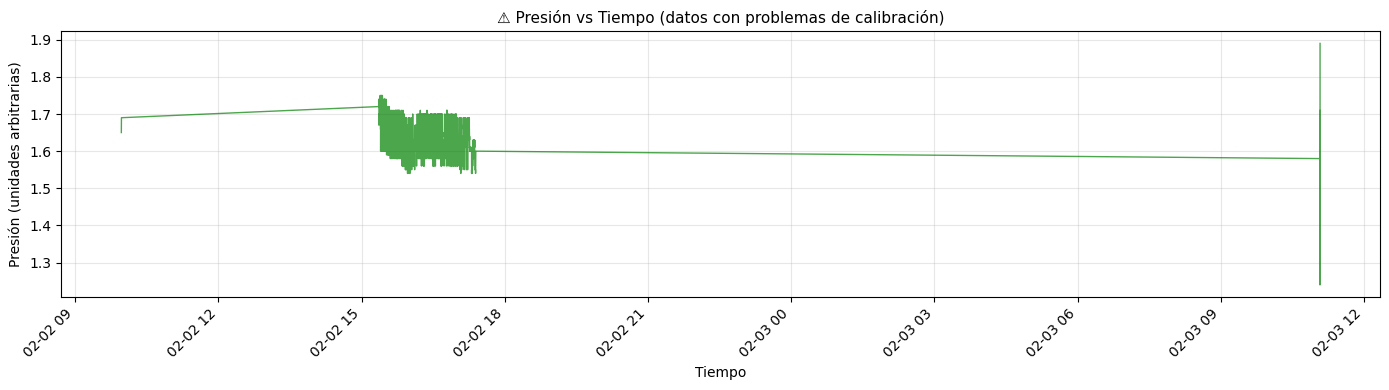

📊 Estadísticas de presión:
   Rango: [1.24, 1.89]
   Media: 1.63
   Std: 0.04
   Puntos válidos: 7,354


In [ ]:
# Plot simple de presión vs tiempo (datos con problemas conocidos)
fig, ax = plt.subplots(1, 1, figsize=(14, 4))

# Extraer tiempos de presión y datos
times_press_raw = press_data["t"]
times_press = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in times_press_raw])

# Verificar dimensiones de press_raw y seleccionar primer sensor si es necesario
if len(press_raw.shape) > 1:
    press_data_plot = press_raw[:, 0]  # Usar primer sensor de presión
else:
    press_data_plot = press_raw

# Filtrar valores positivos
press_valid_mask = press_data_plot > 0
times_press_valid = times_press[press_valid_mask]
press_valid = press_data_plot[press_valid_mask]

if len(press_valid) > 0:
    ax.plot(times_press_valid, press_valid, 'g-', linewidth=1.0, alpha=0.7)
    ax.set_xlabel('Tiempo', fontsize=10)
    ax.set_ylabel('Presión (unidades arbitrarias)', fontsize=10)
    ax.set_title('⚠️ Presión vs Tiempo (datos con problemas de calibración)', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Rotar etiquetas del eje X
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')
    
    plt.tight_layout()
    plt.show()
    
    print(f"📊 Estadísticas de presión:")
    print(f"   Rango: [{np.min(press_valid):.2f}, {np.max(press_valid):.2f}]")
    print(f"   Media: {np.mean(press_valid):.2f}")
    print(f"   Std: {np.std(press_valid):.2f}")
    print(f"   Puntos válidos: {len(press_valid):,}")
else:
    print("⚠️ No hay datos válidos de presión para mostrar")

## 3️⃣ Filtrar Rango Temporal (16:00-17:30)

In [ ]:
# Usar times_all que ya incluye el TIME_SHIFT aplicado
times = times_all  # Ya tiene el shift de 2h aplicado

print(f"📅 Rango COMPLETO de datos disponible (wavelength con TIME_SHIFT aplicado):")
print(f"   Inicio: {times[0].strftime('%Y-%m-%d %H:%M:%S')}")
print(f"   Fin:    {times[-1].strftime('%Y-%m-%d %H:%M:%S')}")

# ============================================================================
# ⬅️ AJUSTA AQUÍ EL RANGO TEMPORAL QUE QUIERES ANALIZAR
# ============================================================================
# Opción A: Usar TODO el rango disponible
use_full_range = False  # Cambiar a True para analizar todos los datos

if use_full_range:
    t_inicio = times[0]
    t_fin = times[-1]
else:
    # Opción B: Definir rango específico manualmente
    # ⚠️ AJUSTA ESTOS VALORES según el rango que viste arriba
    fecha = datetime.date(2026, 2, 2)  # ⬅️ CAMBIAR según tu archivo (20260202.root)
    t_inicio = datetime.datetime.combine(fecha, datetime.time(16, 0))
    t_fin = datetime.datetime.combine(fecha, datetime.time(18, 0))

# Filtrar wavelength por rango temporal (ya tiene shift aplicado)
mask_time = (times >= t_inicio) & (times <= t_fin)
times_filtered = times[mask_time]
wav_filtered = wav_raw[mask_time]

# Filtrar temperatura usando sus propios tiempos (sin shift)
mask_time_temp = (times_temp >= t_inicio) & (times_temp <= t_fin)
temp_filtered = temp_raw[mask_time_temp]
times_temp_filtered = times_temp[mask_time_temp]

print(f"\n✅ Rango seleccionado para análisis:")
print(f"   {t_inicio.strftime('%Y-%m-%d %H:%M')} - {t_fin.strftime('%H:%M')}")
print(f"   Puntos en el rango: {len(times_filtered):,}")

if len(times_filtered) == 0:
    print(f"\n⚠️ ADVERTENCIA: No hay datos en el rango especificado!")
    print(f"\n💡 Soluciones:")
    print(f"   1. Cambia 'use_full_range = True' para usar todos los datos")
    print(f"   2. O ajusta 't_inicio' y 't_fin' según el rango disponible (ver arriba)")

📅 Rango COMPLETO de datos disponible (wavelength con TIME_SHIFT aplicado):
   Inicio: 2026-02-02 11:49:05
   Fin:    2026-02-02 18:18:24

✅ Rango seleccionado para análisis:
   2026-02-02 16:00 - 18:00
   Puntos en el rango: 897,825


## 4️⃣ Análisis de Temperatura (8 RTDs)

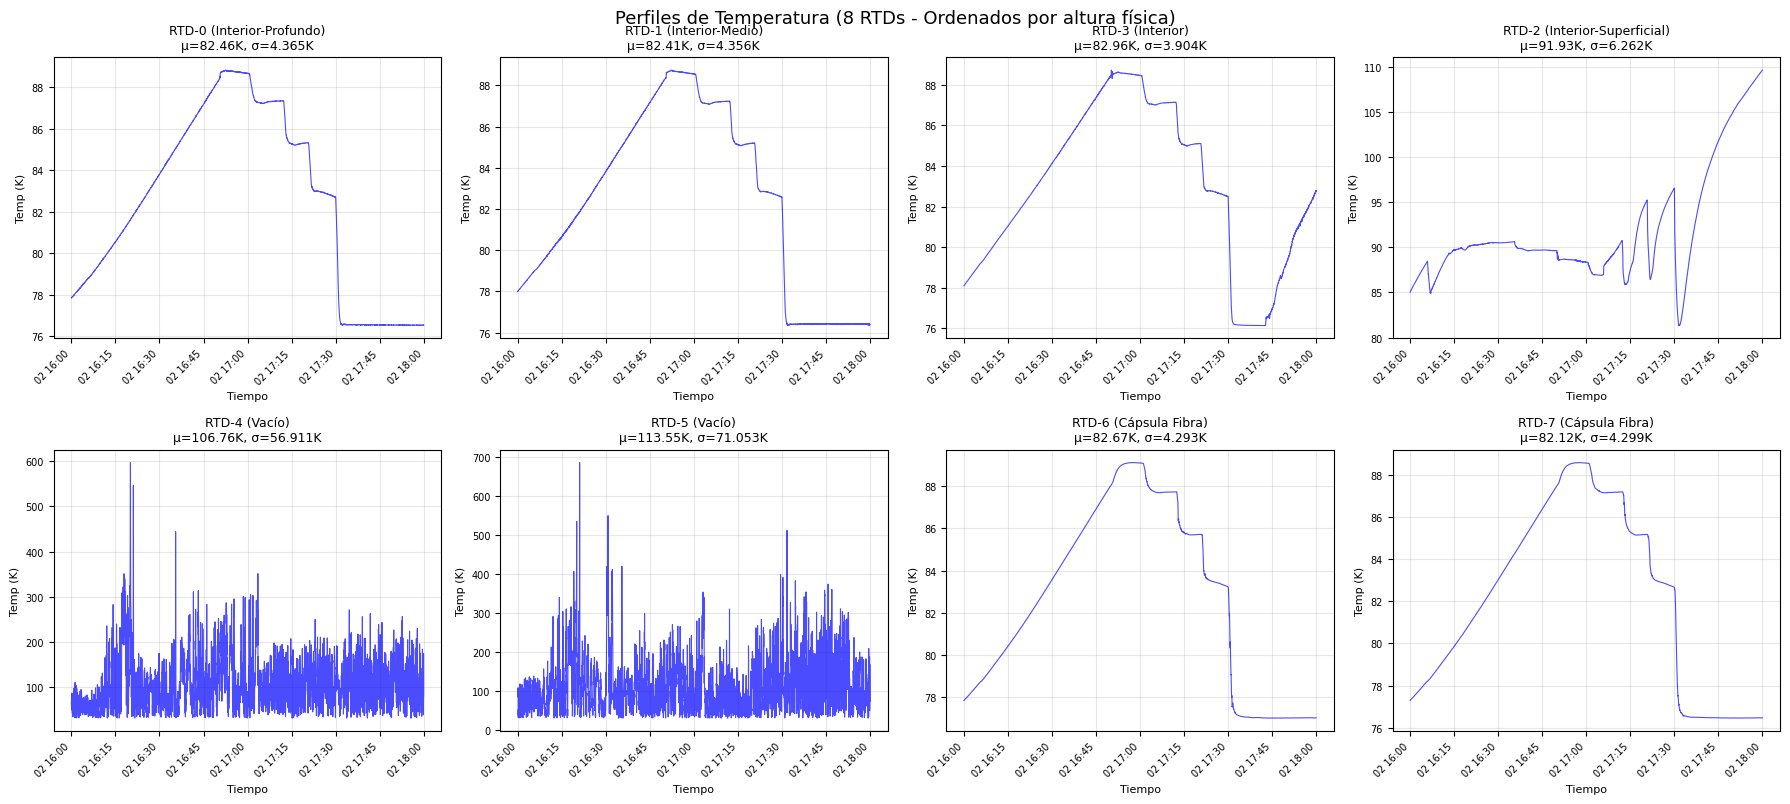


📊 Estadísticas (ordenados por altura física):
RTD-0 (Interior-Profundo)     : μ= 82.46K  σ= 4.365K
RTD-1 (Interior-Medio)        : μ= 82.41K  σ= 4.356K
RTD-3 (Interior)              : μ= 82.96K  σ= 3.904K
RTD-2 (Interior-Superficial)  : μ= 91.93K  σ= 6.262K
RTD-4 (Vacío)                 : μ=106.76K  σ=56.911K
RTD-5 (Vacío)                 : μ=113.55K  σ=71.053K
RTD-6 (Cápsula Fibra)         : μ= 82.67K  σ= 4.293K
RTD-7 (Cápsula Fibra)         : μ= 82.12K  σ= 4.299K


In [ ]:
# Configuración RTDs en orden de altura física (de abajo arriba en la vasija)
rtd_sensors_ordered = [
    (0, "RTD-0 (Interior-Profundo)"),      # Más cercano al suelo
    (1, "RTD-1 (Interior-Medio)"),         # Medio
    (3, "RTD-3 (Interior)"),               # Siguiente altura
    (2, "RTD-2 (Interior-Superficial)"),   # Más externo/superficial
    (4, "RTD-4 (Vacío)"),                  # Vacío
    (5, "RTD-5 (Vacío)"),                  # Vacío
    (6, "RTD-6 (Cápsula Fibra)"),          # Dentro de cápsula
    (7, "RTD-7 (Cápsula Fibra)")           # Dentro de cápsula
]

# Plot
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, (sensor_idx, sensor_name) in enumerate(rtd_sensors_ordered):
    temp_sensor = temp_filtered[:, sensor_idx]
    mask_valid = temp_sensor > 0
    times_valid = times_temp_filtered[mask_valid]
    temp_valid = temp_sensor[mask_valid]
    
    if len(temp_valid) > 0:
        axes[idx].plot(times_valid, temp_valid, 'b-', linewidth=0.8, alpha=0.7)
        axes[idx].set_title(f"{sensor_name}\nμ={np.mean(temp_valid):.2f}K, σ={np.std(temp_valid):.3f}K", fontsize=9)
        axes[idx].set_xlabel('Tiempo', fontsize=8)
        axes[idx].set_ylabel('Temp (K)', fontsize=8)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].tick_params(labelsize=7)
        for label in axes[idx].get_xticklabels():
            label.set_rotation(45)
            label.set_ha('right')

plt.tight_layout()
plt.suptitle('Perfiles de Temperatura (8 RTDs - Ordenados por altura física)', fontsize=13, y=1.00)
plt.show()

print("\n📊 Estadísticas (ordenados por altura física):")
for sensor_idx, sensor_name in rtd_sensors_ordered:
    temp_sensor = temp_filtered[:, sensor_idx]
    mask_valid = temp_sensor > 0
    temp_valid = temp_sensor[mask_valid]
    if len(temp_valid) > 0:
        print(f"{sensor_name:30s}: μ={np.mean(temp_valid):6.2f}K  σ={np.std(temp_valid):6.3f}K")

## 5️⃣ Procesamiento FBG: Filtrado y Media de Polarizaciones

### 5.1 Configuración de 4 Sensores FBG

In [ ]:
# ⚠️ CONFIGURACIÓN: Solo 3 sensores funcionales (FBG-4 omitido)
# FBG-4 (sensor 3) no tiene datos en este dataset (desconectado/fallo de hardware)
# 3 sensores × 2 polarizaciones = 6 canales
# Índices 0-based: sensor 0, 1, 2 (Python indexing)
fbg_config = [
    {"pol": 0, "sensor": 0, "label": "FBG-1-P"},
    {"pol": 1, "sensor": 0, "label": "FBG-1-S"},
    {"pol": 0, "sensor": 1, "label": "FBG-2-P"},
    {"pol": 1, "sensor": 1, "label": "FBG-2-S"},
    {"pol": 0, "sensor": 2, "label": "FBG-3-P"},
    {"pol": 1, "sensor": 2, "label": "FBG-3-S"},
    # FBG-4-P y FBG-4-S OMITIDOS (sensor 3 sin datos)
]

print(f"✅ Configurados {len(fbg_config)} canales FBG (3 sensores × 2 polarizaciones)")
print(f"⚠️  FBG-4 omitido (sin datos en esta adquisición)")

✅ Configurados 6 canales FBG (3 sensores × 2 polarizaciones)
⚠️  FBG-4 omitido (sin datos en esta adquisición)


### 5.2 Filtrado Wavelength (μ±3σ)

In [ ]:
def filter_wavelength_data(wav_data, timestamps, sigma_threshold=3.0):
    """Filtra wavelength usando método μ±3σ"""
    mask_positive = wav_data > 0
    wav_positive = wav_data[mask_positive]
    
    # Si no hay datos válidos, retornar estructura vacía
    if len(wav_positive) == 0:
        return {
            "timestamps": np.array([]),
            "wavelength": np.array([]),
            "mean": np.nan,
            "std": np.nan,
            "n_valid": 0
        }
    
    mean_wav = np.mean(wav_positive)
    std_wav = np.std(wav_positive)
    threshold_min = mean_wav - sigma_threshold * std_wav
    threshold_max = mean_wav + sigma_threshold * std_wav
    
    mask_filtered = (wav_data > 0) & (wav_data >= threshold_min) & (wav_data <= threshold_max)
    
    return {
        "timestamps": timestamps[mask_filtered],
        "wavelength": wav_data[mask_filtered],
        "mean": mean_wav,
        "std": std_wav,
        "n_valid": np.sum(mask_filtered)
    }

# DIAGNÓSTICO: Verificar forma y valores de los sensores
print(f"🔍 Forma de wav_filtered: {wav_filtered.shape}")
print(f"   Dimensiones: (time={wav_filtered.shape[0]}, pol={wav_filtered.shape[1]}, sensor={wav_filtered.shape[2]})")

# Diagnóstico por sensor (solo sensores funcionales: 0, 1, 2)
print(f"\n🔍 Diagnóstico de valores por sensor (solo FBG-1, FBG-2, FBG-3):")
for sensor_idx in range(3):  # Solo 0, 1, 2 (FBG-4 omitido)
    for pol_idx in range(2):
        pol_name = "P" if pol_idx == 0 else "S"
        sensor_data = wav_filtered[:, pol_idx, sensor_idx]
        n_positive = np.sum(sensor_data > 0)
        if n_positive > 0:
            min_val = np.min(sensor_data[sensor_data > 0])
            max_val = np.max(sensor_data)
            mean_val = np.mean(sensor_data[sensor_data > 0])
        else:
            min_val = max_val = mean_val = 0
        
        print(f"   FBG-{sensor_idx+1}-{pol_name}: {n_positive:7d} pts > 0, range=[{min_val:.2f}, {max_val:.2f}] nm, μ={mean_val:.2f} nm")

# Procesar solo canales configurados (FBG-4 excluido)
fbg_filtered_data = {}
for cfg in fbg_config:
    wav_data = wav_filtered[:, cfg["pol"], cfg["sensor"]]  # (time, pol, sensor)
    fbg_filtered_data[cfg["label"]] = filter_wavelength_data(wav_data, times_filtered)

print("\n✅ Filtrado completado (solo sensores funcionales)")
print(f"\n{'Sensor':<12} {'Mean (nm)':<12} {'Std (nm)':<12} {'N válidos'}")
print("="*60)
for label, data in fbg_filtered_data.items():
    print(f"{label:<12} {data['mean']:<12.6f} {data['std']:<12.6f} {data['n_valid']}")

🔍 Forma de wav_filtered: (897825, 2, 4)
   Dimensiones: (time=897825, pol=2, sensor=4)

🔍 Diagnóstico de valores por sensor (solo FBG-1, FBG-2, FBG-3):
   FBG-1-P:  897825 pts > 0, range=[1543.02, 1543.08] nm, μ=1543.05 nm
   FBG-1-S:  897825 pts > 0, range=[1543.02, 1543.09] nm, μ=1543.05 nm
   FBG-2-P:  897825 pts > 0, range=[1548.82, 1548.88] nm, μ=1548.84 nm
   FBG-2-S:  897825 pts > 0, range=[1548.82, 1548.88] nm, μ=1548.85 nm
   FBG-3-P:  624369 pts > 0, range=[1554.60, 1554.65] nm, μ=1554.62 nm
   FBG-3-S:  897825 pts > 0, range=[1554.60, 1554.66] nm, μ=1554.63 nm

✅ Filtrado completado (solo sensores funcionales)

Sensor       Mean (nm)    Std (nm)     N válidos
FBG-1-P      1543.046140  0.020055     897825
FBG-1-S      1543.054548  0.020281     897825
FBG-2-P      1548.841921  0.020042     897825
FBG-2-S      1548.851087  0.020357     897825
FBG-3-P      1554.624866  0.022216     624369
FBG-3-S      1554.628858  0.020916     897825


### 5.3 Calcular Media de Polarizaciones

In [ ]:
# Calcular media P+S para cada sensor (solo sensores funcionales: 1, 2, 3)
# FBG-4 omitido (sin datos)
fbg_mean_data = {}

for sensor_num in [1, 2, 3]:  # Solo sensores funcionales (FBG-4 excluido)
    label_p = f"FBG-{sensor_num}-P"
    label_s = f"FBG-{sensor_num}-S"
    label_mean = f"FBG-{sensor_num}-Mean"
    
    data_p = fbg_filtered_data[label_p]
    data_s = fbg_filtered_data[label_s]
    
    times_p = data_p["timestamps"]
    times_s = data_s["timestamps"]
    wav_p = data_p["wavelength"]
    wav_s = data_s["wavelength"]
    
    # Verificar que hay datos válidos
    if len(times_p) == 0 or len(times_s) == 0:
        print(f"⚠️ FBG-{sensor_num} no tiene datos suficientes, omitiendo...")
        continue
    
    # Interpolar S a tiempos de P
    times_p_sec = np.array([t.timestamp() for t in times_p])
    times_s_sec = np.array([t.timestamp() for t in times_s])
    wav_s_interp = np.interp(times_p_sec, times_s_sec, wav_s)
    
    # Media
    wav_mean = (wav_p + wav_s_interp) / 2.0
    
    fbg_mean_data[label_mean] = {
        "timestamps": times_p,
        "wavelength": wav_mean,
        "mean": np.mean(wav_mean),
        "std": np.std(wav_mean),
        "n_valid": len(wav_mean),
        "sensor_num": sensor_num
    }

print("✅ Medias calculadas (P+S)/2 para sensores funcionales")
print(f"\n{'Sensor':<15} {'Mean (nm)':<15} {'Std (nm)':<15} {'N puntos'}")
print("="*65)
for label, data in fbg_mean_data.items():
    print(f"{label:<15} {data['mean']:<15.6f} {data['std']:<15.6f} {data['n_valid']}")

✅ Medias calculadas (P+S)/2 para sensores funcionales

Sensor          Mean (nm)       Std (nm)        N puntos
FBG-1-Mean      1543.050344     0.020025        897825
FBG-2-Mean      1548.846504     0.020158        897825
FBG-3-Mean      1554.627731     0.022672        624369


### 5.4 Visualizar Wavelengths (Media de Polarizaciones)

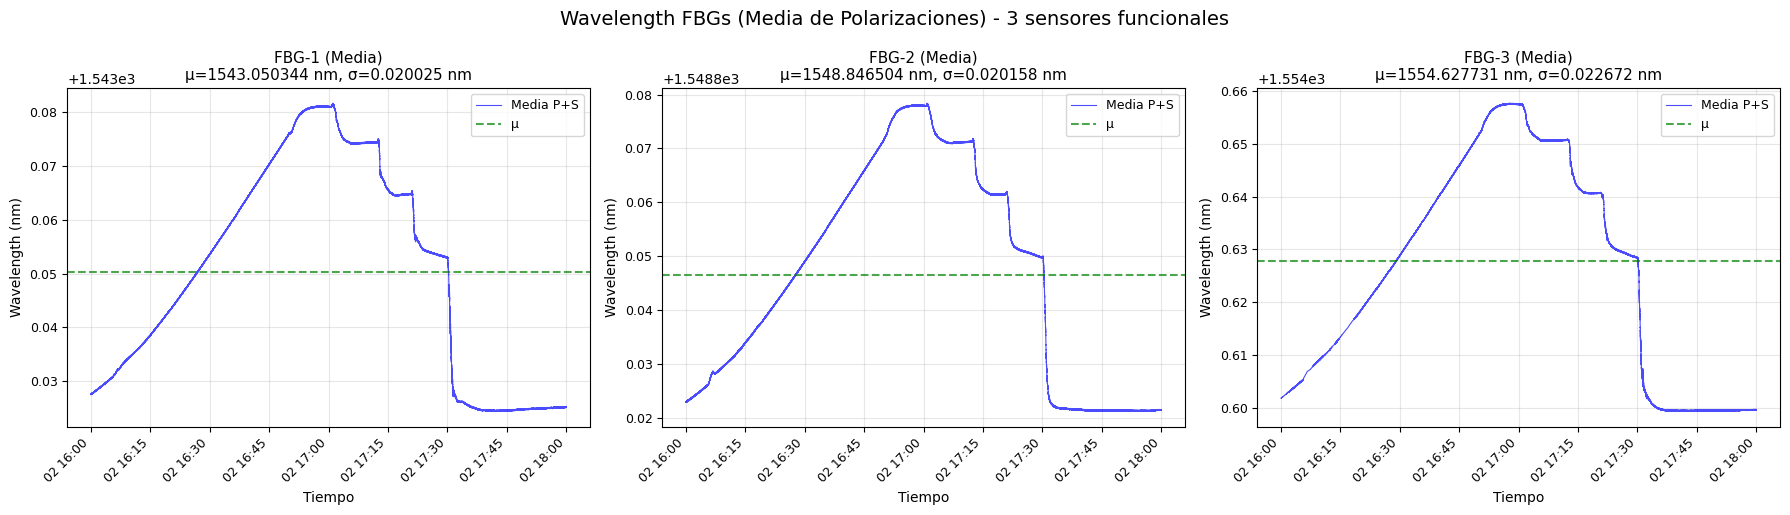

In [ ]:
# Ajustar layout para 3 sensores (FBG-4 omitido)
n_sensors = len(fbg_mean_data)
if n_sensors == 3:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
elif n_sensors == 4:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
else:
    fig, axes = plt.subplots(1, n_sensors, figsize=(6*n_sensors, 5))

if n_sensors == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, (label, data) in enumerate(fbg_mean_data.items()):
    times_fbg = data["timestamps"]
    wav_fbg = data["wavelength"]
    sensor_num = data["sensor_num"]
    
    axes[idx].plot(times_fbg, wav_fbg, 'b-', linewidth=0.8, alpha=0.7, label='Media P+S')
    axes[idx].axhline(data['mean'], color='g', linestyle='--', linewidth=1.5, alpha=0.7, label='μ')
    
    axes[idx].set_title(f"FBG-{sensor_num} (Media)\nμ={data['mean']:.6f} nm, σ={data['std']:.6f} nm", fontsize=11)
    axes[idx].set_xlabel('Tiempo', fontsize=10)
    axes[idx].set_ylabel('Wavelength (nm)', fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=9)
    axes[idx].tick_params(labelsize=9)
    
    for tick_label in axes[idx].get_xticklabels():
        tick_label.set_rotation(45)
        tick_label.set_ha('right')

plt.tight_layout()
plt.suptitle(f'Wavelength FBGs (Media de Polarizaciones) - {n_sensors} sensores funcionales', fontsize=14, y=1.02)
plt.show()

## 6️⃣ Correlación Temperatura - Wavelength

### 6.1 Seleccionar RTD de Referencia

In [ ]:
# Usar RTD-6 (cápsula fibra) como referencia
rtd_ref_idx = 6
rtd_ref_name = "RTD-6 (Cápsula)"

temp_ref = temp_filtered[:, rtd_ref_idx]
mask_temp_valid = temp_ref > 0
times_temp_ref = times_temp_filtered[mask_temp_valid]
temp_ref_valid = temp_ref[mask_temp_valid]

print(f"✅ Referencia: {rtd_ref_name}")
print(f"   Rango: [{np.min(temp_ref_valid):.2f}, {np.max(temp_ref_valid):.2f}] K")

✅ Referencia: RTD-6 (Cápsula)
   Rango: [77.01, 89.12] K


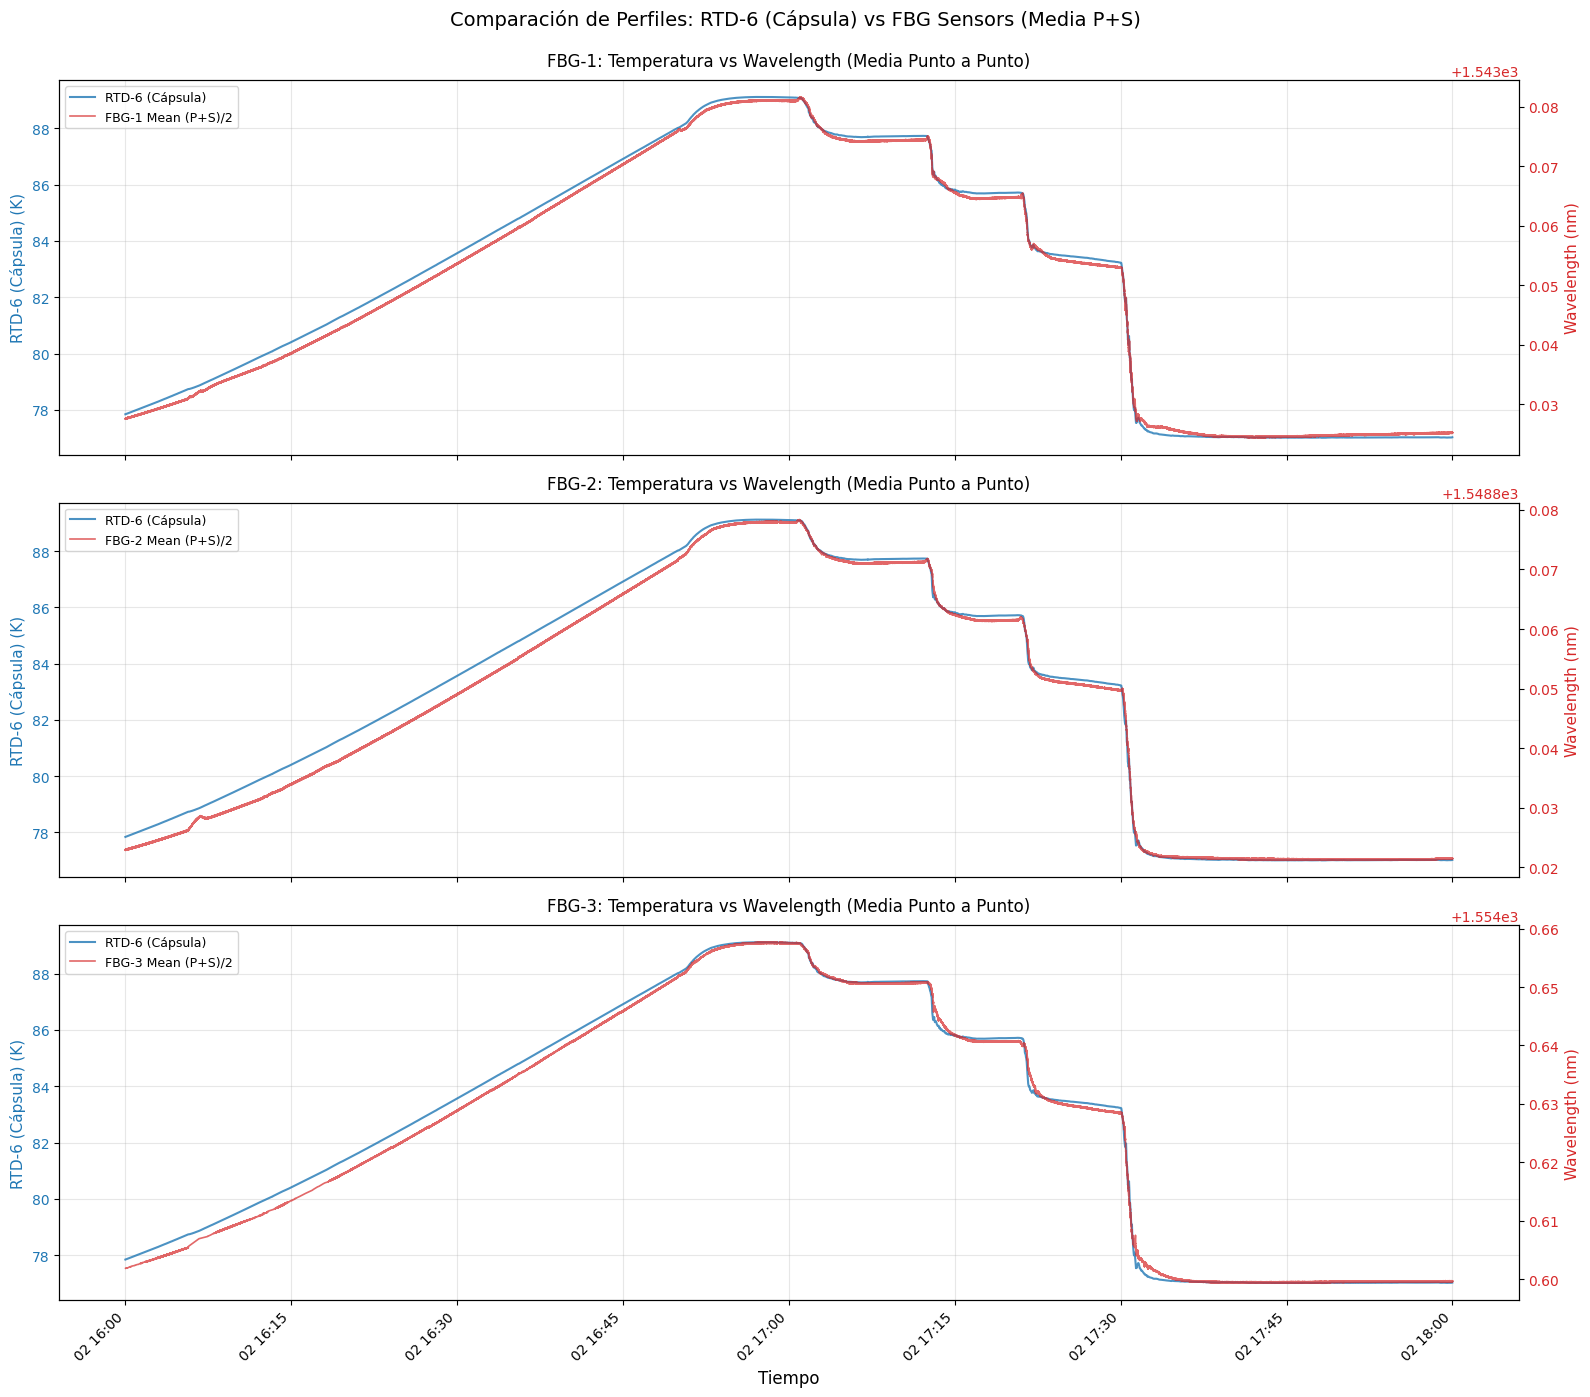

✅ Gráficos superpuestos generados para 3 sensores FBG
   💡 Ejecuta primero la celda 6.3 para ver los plateaus marcados


In [ ]:
# Superposición de temperatura con cada sensor FBG (3 subplots)
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

color_temp = 'tab:blue'
color_wav = 'tab:red'

for idx, sensor_num in enumerate([1, 2, 3]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    fbg_data_plot = fbg_mean_data[fbg_label]
    
    ax1 = axes[idx]
    
    # Eje izquierdo: Temperatura
    ax1.set_ylabel(f'{rtd_ref_name} (K)', fontsize=11, color=color_temp)
    ax1.plot(times_temp_ref, temp_ref_valid, color=color_temp, linewidth=1.5, alpha=0.8, label=rtd_ref_name)
    ax1.tick_params(axis='y', labelcolor=color_temp)
    ax1.grid(True, alpha=0.3, axis='both')
    
    # Marcar plateaus con líneas verticales (si están definidos)
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for plateau in plateau_data:
            ax1.axvline(plateau["t0"], color='red', linestyle='--', linewidth=1.5, alpha=0.6)
            ax1.axvline(plateau["tfin"], color='blue', linestyle='--', linewidth=1.5, alpha=0.6)
    
    # Eje derecho: Wavelength (media punto a punto P+S)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Wavelength (nm)', fontsize=11, color=color_wav)
    ax2.plot(fbg_data_plot["timestamps"], fbg_data_plot["wavelength"], 
             color=color_wav, linewidth=1.2, alpha=0.7, 
             label=f'FBG-{sensor_num} Mean (P+S)/2')
    ax2.tick_params(axis='y', labelcolor=color_wav)
    
    # Leyendas combinadas
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    
    # Añadir leyenda para plateaus si existen
    if 'plateau_data' in globals() and len(plateau_data) > 0 and idx == 0:
        from matplotlib.lines import Line2D
        custom_lines = [Line2D([0], [0], color='red', linestyle='--', linewidth=1.5),
                       Line2D([0], [0], color='blue', linestyle='--', linewidth=1.5)]
        ax1.legend(lines1 + lines2 + custom_lines, 
                  labels1 + labels2 + ['Inicio plateau', 'Fin plateau'], 
                  loc='upper left', fontsize=9)
    else:
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    
    # Título del subplot
    ax1.set_title(f'FBG-{sensor_num}: Temperatura vs Wavelength (Media Punto a Punto)', 
                  fontsize=12, pad=10)

# Solo en el último subplot
axes[-1].set_xlabel('Tiempo', fontsize=12)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Comparación de Perfiles: {rtd_ref_name} vs FBG Sensors (Media P+S)', 
             fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

print(f"✅ Gráficos superpuestos generados para 3 sensores FBG")
if 'plateau_data' in globals() and len(plateau_data) > 0:
    print(f"   🔴🔵 Plateaus marcados con líneas verticales (rojo=inicio, azul=fin)")
else:
    print(f"   💡 Ejecuta primero la celda 6.3 para ver los plateaus marcados")

📋 Primeras líneas de: /eos/user/j/jcapotor/FBGdata/Data/pressure_setup/20260202/temperatures_1.txt
  2/2/2026	11:50:17 AM	76.59046	76.42103	76.40962	76.35376	93.37126	49.35634	273.03002	272.72040
  2/2/2026	11:50:19 AM	76.60540	76.42547	76.41703	76.36160	48.01519	53.27890	272.69173	272.39013

📋 Primeras líneas de: /eos/user/j/jcapotor/FBGdata/Data/pressure_setup/20260202/peaks_1.txt
  02-Feb-2026 11:50:48.937931	3979018248937931885	0	871577236	Channel 1	Fibre 1	Sensor 1	1	1.544761613050E-6	1.440470000000E-3	Channel 1	Fibre 1	Sensor 2	1	1.550300183388E-6	1.336770000000E-3	Channel 1	Fibre 1	Sensor 3	1	1.556397331841E-6	1.223463000000E-3	Channel 1	Fibre 1	Sensor 4	1	1.562016186583E-6	1.119826500000E-3
  02-Feb-2026 11:50:48.941932	3979018248941931889	0	871577240	Channel 1	Fibre 1	Sensor 1	1	1.544759082726E-6	1.440518000000E-3	Channel 1	Fibre 1	Sensor 2	1	1.550299802165E-6	1.336777000000E-3	Channel 1	Fibre 1	Sensor 3	1	1.556394175754E-6	1.223522000000E-3	Channel 1	Fibre 1	Sensor 4	1	1.5620

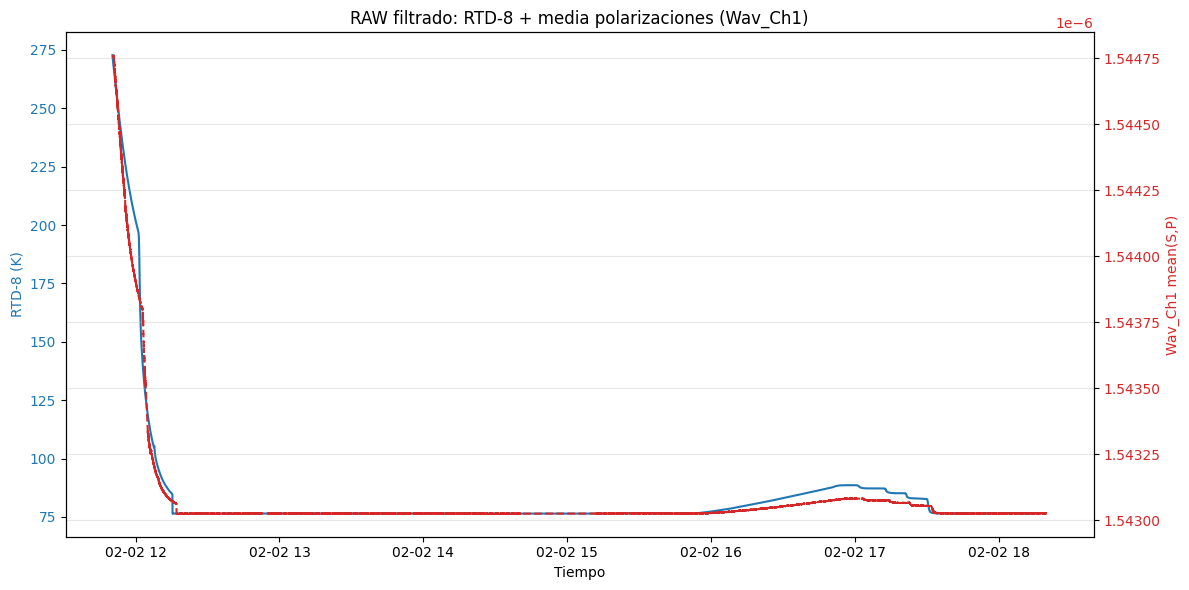


🕓 Ventana 12:00-13:00 -> Temp: 1,791 pts | Wav mean(S,P): 441,386 pares


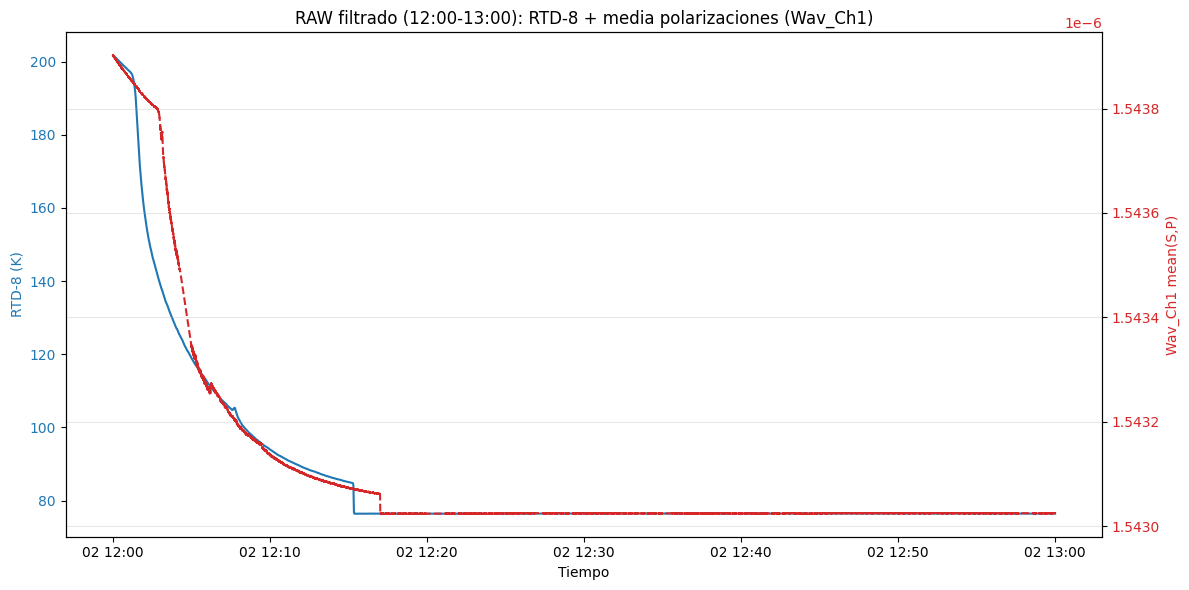

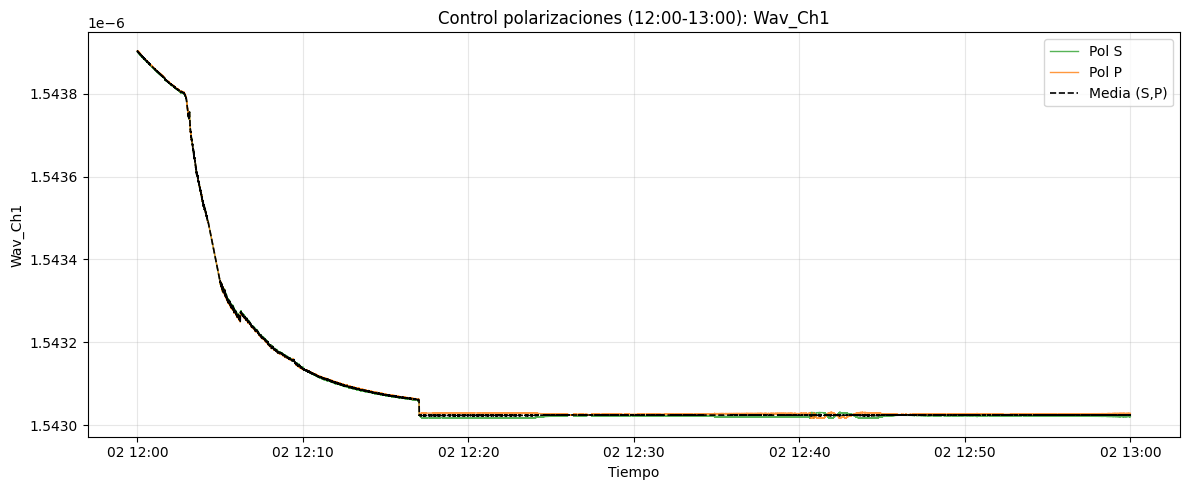

In [ ]:
import glob
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1) Ruta de datos
folder_path = "/eos/user/j/jcapotor/FBGdata/Data/pressure_setup/20260202/"

# 2) Configuración: solo 1 RTD + 1 WAV
rtd_objetivo = "RTD-8"
active_wav = "Wav_Ch1"

# Polarizaciones alternadas por línea: S, P, S, P, ...
pol_start = "S"  # primera línea de cada secuencia

# True = usa TODO el rango disponible
# False = usa ventana manual
use_full_range = True
T_INICIO = "2026-02-02 12:00:00"
T_FIN    = "2026-02-02 13:00:00"

# ==========================================
# 🔴 CARGAR Y FILTRAR SOLO EL RTD OBJETIVO
# ==========================================
temp_files = sorted(glob.glob(os.path.join(folder_path, "temperatures_*.txt")))
headers_temp = ["Date", "Time_str", "RTD-1", "RTD-2", "RTD-3", "RTD-4", "RTD-5", "RTD-6", "RTD-7", "RTD-8"]

if len(temp_files) == 0:
    raise FileNotFoundError(f"No se encontraron archivos temperatures_*.txt en: {folder_path}")

# 📋 Ver primeras líneas de temperature_1.txt
print(f"📋 Primeras líneas de: {temp_files[0]}")
with open(temp_files[0], "r") as f:
    for i in range(2):
        print(f"  {f.readline().strip()}")

df_temp_list = []
for file in temp_files:
    df_single = pd.read_csv(
        file,
        sep="\t",
        header=None,
        names=headers_temp,
        usecols=["Date", "Time_str", rtd_objetivo]
    )
    df_temp_list.append(df_single)

df_temp_raw = pd.concat(df_temp_list, ignore_index=True)

df_temp_raw["Time_Datetime"] = pd.to_datetime(
    df_temp_raw["Date"] + " " + df_temp_raw["Time_str"],
    format="%d/%m/%Y %I:%M:%S %p",
    errors="coerce"
)
df_temp_raw = df_temp_raw.dropna(subset=["Time_Datetime"])

df_temp_raw[rtd_objetivo] = pd.to_numeric(df_temp_raw[rtd_objetivo], errors="coerce")
df_temp_raw = df_temp_raw[(df_temp_raw[rtd_objetivo] > 1.0) & (df_temp_raw[rtd_objetivo] < 400.0)]

# ==========================================
# 🔵 CARGAR TODOS LOS peaks_*.txt y FILTRAR SOLO 1 WAV
# ==========================================
peak_files = sorted(glob.glob(os.path.join(folder_path, "peaks_*.txt")))
if len(peak_files) == 0:
    raise FileNotFoundError(f"No se encontraron archivos peaks_*.txt en: {folder_path}")

# 📋 Ver primeras líneas de peaks_1.txt
print(f"\n📋 Primeras líneas de: {peak_files[0]}")
with open(peak_files[0], "r") as f:
    for i in range(2):
        print(f"  {f.readline().strip()}")

with open(peak_files[0], "r") as f:
    first_line = f.readline().split("\t")
n_sensors = int((len(first_line) - 4) / 6)

headers_peaks = ["timeStamp", "epochTime_str", "errorFlag0", "sweepNumber"]
all_wav_columns = []
for i in range(n_sensors):
    channel = f"Ch{i+1}"
    wav_name = f"Wav_{channel}"
    all_wav_columns.append(wav_name)
    headers_peaks.extend([f"chS{i+1}", f"fibS{i+1}", f"sens{i+1}", f"errS{i+1}", wav_name, f"Ptime_{channel}"])

if active_wav not in all_wav_columns:
    raise ValueError(f"{active_wav} no existe. Opciones: {all_wav_columns}")

df_peak_list = []
for file in peak_files:
    df_single = pd.read_csv(
        file,
        sep="\t",
        header=None,
        names=headers_peaks,
        dtype={"timeStamp": str, "epochTime_str": str},
        on_bad_lines="skip",
        usecols=["timeStamp", "epochTime_str", active_wav]
    )
    df_peak_list.append(df_single)

df_peak_raw = pd.concat(df_peak_list, ignore_index=True)

fecha_combinada = df_peak_raw["timeStamp"].str.strip() + " " + df_peak_raw["epochTime_str"].str.strip()
fecha_combinada_limpia = fecha_combinada.apply(
    lambda x: x.split(".")[0] + "." + "".join(filter(str.isdigit, x.split(".")[1]))[:6] if "." in str(x) else x
)

df_peak_raw["Time_Datetime"] = pd.to_datetime(
    fecha_combinada_limpia,
    format="%d-%b-%Y %H:%M:%S.%f",
    errors="coerce"
)
df_peak_raw = df_peak_raw.dropna(subset=["Time_Datetime"])

# Filtrar SOLO la WAV activa (no todas)
df_peak_raw[active_wav] = pd.to_numeric(df_peak_raw[active_wav], errors="coerce")
if df_peak_raw[active_wav].mean() < 1e-3:  # en metros
    df_peak_raw = df_peak_raw[(df_peak_raw[active_wav] > 1e-6) & (df_peak_raw[active_wav] < 2e-6)]
else:  # en nanómetros
    df_peak_raw = df_peak_raw[(df_peak_raw[active_wav] > 1400) & (df_peak_raw[active_wav] < 1700)]

# ==========================================
# 🧭 SEPARAR POLARIZACIONES (S/P alternadas) Y PROMEDIAR
# ==========================================
df_peak_raw = df_peak_raw.sort_values("Time_Datetime").reset_index(drop=True)

# Etiquetar polarización alternada por línea
if pol_start.upper() == "S":
    df_peak_raw["pol"] = np.where(np.arange(len(df_peak_raw)) % 2 == 0, "S", "P")
else:
    df_peak_raw["pol"] = np.where(np.arange(len(df_peak_raw)) % 2 == 0, "P", "S")

# Agrupar cada par (S,P) consecutivo para calcular media
df_peak_raw["pair_id"] = np.arange(len(df_peak_raw)) // 2

df_peak_pairs = df_peak_raw.pivot_table(
    index="pair_id",
    columns="pol",
    values=active_wav,
    aggfunc="first"
)

# Timestamp representativo del par: primer timestamp del par
df_time_pairs = df_peak_raw.groupby("pair_id", as_index=False)["Time_Datetime"].first()

# Construir dataframe con media de polarizaciones
df_peak_mean = df_time_pairs.copy()
df_peak_mean = df_peak_mean.merge(df_peak_pairs, left_on="pair_id", right_index=True, how="left")
df_peak_mean["wav_mean"] = df_peak_mean[["S", "P"]].mean(axis=1)
df_peak_mean = df_peak_mean.dropna(subset=["wav_mean"])

# ==========================================
# ⏳ RANGO TEMPORAL
# ==========================================
if use_full_range:
    t0 = min(df_temp_raw["Time_Datetime"].min(), df_peak_mean["Time_Datetime"].min())
    t1 = max(df_temp_raw["Time_Datetime"].max(), df_peak_mean["Time_Datetime"].max())
else:
    t0 = pd.to_datetime(T_INICIO)
    t1 = pd.to_datetime(T_FIN)

df_temp_zoom = df_temp_raw[(df_temp_raw["Time_Datetime"] >= t0) & (df_temp_raw["Time_Datetime"] <= t1)]
df_peak_zoom = df_peak_mean[(df_peak_mean["Time_Datetime"] >= t0) & (df_peak_mean["Time_Datetime"] <= t1)]

print(f"📁 peaks_*.txt cargados: {len(peak_files)}")
print(f"🔴 {rtd_objetivo}: {df_temp_zoom['Time_Datetime'].min()} -> {df_temp_zoom['Time_Datetime'].max()} ({len(df_temp_zoom):,} pts)")
print(f"🔵 {active_wav} (S/P medias): {df_peak_zoom['Time_Datetime'].min()} -> {df_peak_zoom['Time_Datetime'].max()} ({len(df_peak_zoom):,} pares)")

# ==========================================
# 📊 GRAFICAR RTD + MEDIA(S,P) (rango principal)
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 6))

color = "tab:blue"
ax1.set_xlabel("Tiempo")
ax1.set_ylabel(f"{rtd_objetivo} (K)", color=color)
ax1.plot(df_temp_zoom["Time_Datetime"], df_temp_zoom[rtd_objetivo], color=color, label=rtd_objetivo)
ax1.tick_params(axis="y", labelcolor=color)

ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel(f"{active_wav} mean(S,P)", color=color)
ax2.plot(df_peak_zoom["Time_Datetime"], df_peak_zoom["wav_mean"], color=color, linestyle="--", label="mean(S,P)")
ax2.tick_params(axis="y", labelcolor=color)

plt.title(f"RAW filtrado: {rtd_objetivo} + media polarizaciones ({active_wav})")
fig.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# 📊 GRAFICAR RTD + MEDIA(S,P) (zoom fijo 12:00-13:00)
# ==========================================
t0_12_13 = pd.to_datetime("2026-02-02 12:00:00")
t1_12_13 = pd.to_datetime("2026-02-02 13:00:00")

df_temp_12_13 = df_temp_raw[(df_temp_raw["Time_Datetime"] >= t0_12_13) & (df_temp_raw["Time_Datetime"] <= t1_12_13)]
df_peak_12_13 = df_peak_mean[(df_peak_mean["Time_Datetime"] >= t0_12_13) & (df_peak_mean["Time_Datetime"] <= t1_12_13)]

print(f"\n🕓 Ventana 12:00-13:00 -> Temp: {len(df_temp_12_13):,} pts | Wav mean(S,P): {len(df_peak_12_13):,} pares")

fig, ax1 = plt.subplots(figsize=(12, 6))

color = "tab:blue"
ax1.set_xlabel("Tiempo")
ax1.set_ylabel(f"{rtd_objetivo} (K)", color=color)
ax1.plot(df_temp_12_13["Time_Datetime"], df_temp_12_13[rtd_objetivo], color=color, label=f"{rtd_objetivo} (12-13)")
ax1.tick_params(axis="y", labelcolor=color)

ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel(f"{active_wav} mean(S,P)", color=color)
ax2.plot(df_peak_12_13["Time_Datetime"], df_peak_12_13["wav_mean"], color=color, linestyle="--", label="mean(S,P) 12-13")
ax2.tick_params(axis="y", labelcolor=color)

plt.title(f"RAW filtrado (12:00-13:00): {rtd_objetivo} + media polarizaciones ({active_wav})")
fig.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# 📊 PLOT 3 (CONTROL): POL S y POL P separadas (12:00-13:00)
# ==========================================
if "S" in df_peak_12_13.columns and "P" in df_peak_12_13.columns:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df_peak_12_13["Time_Datetime"], df_peak_12_13["S"], color="tab:green", alpha=0.8, linewidth=1.0, label="Pol S")
    ax.plot(df_peak_12_13["Time_Datetime"], df_peak_12_13["P"], color="tab:orange", alpha=0.8, linewidth=1.0, label="Pol P")
    ax.plot(df_peak_12_13["Time_Datetime"], df_peak_12_13["wav_mean"], color="black", linestyle="--", linewidth=1.2, label="Media (S,P)")
    ax.set_xlabel("Tiempo")
    ax.set_ylabel(active_wav)
    ax.set_title(f"Control polarizaciones (12:00-13:00): {active_wav}")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No se pudieron separar ambas polarizaciones (S y P) para el plot de control.")

### 6.2 Visualización de Perfiles (para definir plateaus)

Superposición de temperatura y wavelength para identificar visualmente los plateaus.

### 6.3 Definición Manual de Plateaus

**✏️ Define aquí los intervalos temporales de plateau identificados en los gráficos anteriores**

In [ ]:
# ============================================================================
# DEFINICIÓN MANUAL DE PLATEAUS (basados en los gráficos de la sección 6.2)
# ============================================================================
# Formato: [("Nombre", "HH:MM", "HH:MM"), ...]

#manual_plateaus = [
    #("Plateau 1", "16:56", "17:01"),
    #("Plateau 2", "17:06", "17:12"),
    #("Plateau 3", "17:17", "17:21"),
    #("Plateau 4", "17:26", "17:30"),
    #("Plateau 5", "17:40", "17:50"),
#]

manual_plateaus = [
    ("Plateau 1", "16:57", "17:01"),  # 4 min (recortado el inicio)
    ("Plateau 2", "17:08", "17:12"),  # 4 min (recortado el inicio)
    ("Plateau 3", "17:17", "17:21"),  # 4 min (se queda igual)
    ("Plateau 4", "17:26", "17:30"),  # 4 min (se queda igual)
    ("Plateau 5", "17:46", "17:50"),  # 4 min (nos quedamos con los últimos 4 min estables)
]

# Activar plateaus manuales
use_manual_plateaus = True

# Procesar plateaus
plateau_data = []

if use_manual_plateaus and len(manual_plateaus) > 0:
    print("✅ Usando plateaus manuales:")
    print("="*70)
    
    for name, t0_str, tfin_str in manual_plateaus:
        t0 = datetime.datetime.combine(fecha, datetime.datetime.strptime(t0_str, "%H:%M").time())
        tfin = datetime.datetime.combine(fecha, datetime.datetime.strptime(tfin_str, "%H:%M").time())
        
        # Calcular media y std de temperatura en el plateau
        mask_temp_plateau = (times_temp_ref >= t0) & (times_temp_ref <= tfin)
        temp_plateau = temp_ref_valid[mask_temp_plateau]
        
        if len(temp_plateau) > 0:
            temp_mean = np.mean(temp_plateau)
            temp_std = np.std(temp_plateau)
            
            plateau_info = {
                "name": name,
                "t0": t0,
                "tfin": tfin,
                "temp_mean": temp_mean,
                "temp_std": temp_std,
                "n_temp_points": len(temp_plateau)
            }
            
            plateau_data.append(plateau_info)
            
            print(f"{name}: {t0_str} - {tfin_str}")
            print(f"  Temperatura: μ={temp_mean:.3f}K, σ={temp_std:.4f}K, n={len(temp_plateau)}")
        else:
            print(f"⚠️ {name}: No hay datos de temperatura en este rango")
    
    print("="*70)
    print(f"\n✅ {len(plateau_data)} plateaus definidos")
else:
    print("ℹ️ Plateaus desactivados")

✅ Usando plateaus manuales:
Plateau 1: 16:57 - 17:01
  Temperatura: μ=89.107K, σ=0.0102K, n=115
Plateau 2: 17:08 - 17:12
  Temperatura: μ=87.722K, σ=0.0062K, n=121
Plateau 3: 17:17 - 17:21
  Temperatura: μ=85.705K, σ=0.0097K, n=121
Plateau 4: 17:26 - 17:30
  Temperatura: μ=83.339K, σ=0.0631K, n=111
Plateau 5: 17:46 - 17:50
  Temperatura: μ=77.013K, σ=0.0034K, n=120

✅ 5 plateaus definidos


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n" + "="*70)
print("🔬 SINCRONIZACIÓN: BÚSQUEDA DEL LAG ÓPTIMO")
print("="*70)

# Usar RTD-8 como referencia real del análisis
rtd_col = "RTD-8" if "RTD-8" in df_temp_raw.columns else rtd_objetivo

print("""
📋 MÉTODO UTILIZADO:
   1. Barrido exhaustivo: prueba lags entre -300s y +300s
   2. Paso de búsqueda: 1 segundo
   3. Para cada lag: calcula el error MAD (Mean Absolute Deviation)
   4. MAD = promedio de diferencias absolutas entre RTD y wavelength
   5. MAD es más robusto que correlación pura para cambios bruscos
   6. Selecciona el lag que minimiza MAD
   
⚠️  PROBLEMA CON CORRELACIÓN SIMPLE:
   - Correlación maximiza similitud global (engañosa)
   - Con cambios bruscos, puede dar un lag incorrecto
   
✓ VENTAJA DE MAD:
   - Minimiza error punto a punto
   - Detecta desfases grandes correctamente
   - Robusto a cambios abruptos (plateaus, transiciones)
""")

# Interpolamos ambas señales a grid común
t_min = pd.to_datetime("2026-02-02 16:00:00")
t_max = pd.to_datetime("2026-02-02 18:00:00")
time_grid = pd.date_range(start=t_min, end=t_max, freq="1s")

mask_temp = (df_temp_raw["Time_Datetime"] >= t_min) & (df_temp_raw["Time_Datetime"] <= t_max)
temp_times_num_filt = df_temp_raw.loc[mask_temp, "Time_Datetime"].astype(np.int64).values
grid_times_num = time_grid.astype(np.int64).values

df_peak_filt = df_peak_raw[(df_peak_raw["Time_Datetime"] >= t_min) & 
                            (df_peak_raw["Time_Datetime"] <= t_max)].copy()
df_peak_filt = df_peak_filt.sort_values("Time_Datetime").reset_index(drop=True)

if pol_start.upper() == "S":
    df_peak_filt["pol"] = np.where(np.arange(len(df_peak_filt)) % 2 == 0, "S", "P")
else:
    df_peak_filt["pol"] = np.where(np.arange(len(df_peak_filt)) % 2 == 0, "P", "S")

df_peak_filt["pair_id"] = np.arange(len(df_peak_filt)) // 2
df_peak_pairs = df_peak_filt.pivot_table(
    index="pair_id", columns="pol", values=active_wav, aggfunc="first"
)
df_time_pairs = df_peak_filt.groupby("pair_id", as_index=False)["Time_Datetime"].first()
df_peak_mean_16_18 = df_time_pairs.copy()
df_peak_mean_16_18 = df_peak_mean_16_18.merge(df_peak_pairs, left_on="pair_id", right_index=True, how="left")
df_peak_mean_16_18["wav_mean"] = df_peak_mean_16_18[["S", "P"]].mean(axis=1)
df_peak_mean_16_18 = df_peak_mean_16_18.dropna(subset=["wav_mean"])

peak_times_num_mean = df_peak_mean_16_18["Time_Datetime"].astype(np.int64).values

# Interpolar
temp_interp = np.interp(grid_times_num, temp_times_num_filt, df_temp_raw.loc[mask_temp, rtd_col].values)
peak_interp = np.interp(grid_times_num, peak_times_num_mean, df_peak_mean_16_18["wav_mean"].values)

# Normalizar
temp_norm = (temp_interp - np.mean(temp_interp)) / (np.std(temp_interp) + 1e-10)
peak_norm = (peak_interp - np.mean(peak_interp)) / (np.std(peak_interp) + 1e-10)

# Barrido de lags con paso de 1 segundo
lag_range = np.arange(-300, 301, 1)
print(f"\n📊 Evaluando {len(lag_range)} lags con paso de 1 segundo...")

mad_errors = []
for test_lag in lag_range:
    peak_shifted = np.roll(peak_norm, test_lag)
    mad = np.mean(np.abs(temp_norm - peak_shifted))
    mad_errors.append(mad)

# Encontrar óptimo
best_lag_mad_idx = np.argmin(mad_errors)
best_lag_final = lag_range[best_lag_mad_idx]
min_mad = mad_errors[best_lag_mad_idx]

print(f"\n✅ RESULTADO:")
print(f"   Referencia usada: {rtd_col}")
print(f"   Lag óptimo: {best_lag_final}s")
print(f"   Error MAD: {min_mad:.6f}")
print(f"   → FBG llega {abs(best_lag_final)}s {'ANTES' if best_lag_final < 0 else 'DESPUÉS'} que {rtd_col}")
print(f"   → Corrección: sumar {-best_lag_final}s a tiempos del FBG")

# Aplicar corrección
desfase_segundos = best_lag_final
df_peak_mean_16_18["Time_Datetime_Corrected"] = (
    df_peak_mean_16_18["Time_Datetime"] + pd.to_timedelta(desfase_segundos, unit="s")
)

print("\n" + "="*70)


🔬 SINCRONIZACIÓN: BÚSQUEDA DEL LAG ÓPTIMO

📋 MÉTODO UTILIZADO:
   1. Barrido exhaustivo: prueba lags entre -300s y +300s
   2. Paso de búsqueda: 1 segundo
   3. Para cada lag: calcula el error MAD (Mean Absolute Deviation)
   4. MAD = promedio de diferencias absolutas entre RTD y wavelength
   5. MAD es más robusto que correlación pura para cambios bruscos
   6. Selecciona el lag que minimiza MAD

⚠️  PROBLEMA CON CORRELACIÓN SIMPLE:
   - Correlación maximiza similitud global (engañosa)
   - Con cambios bruscos, puede dar un lag incorrecto

✓ VENTAJA DE MAD:
   - Minimiza error punto a punto
   - Detecta desfases grandes correctamente
   - Robusto a cambios abruptos (plateaus, transiciones)


📊 Evaluando 601 lags con paso de 1 segundo...

✅ RESULTADO:
   Referencia usada: RTD-8
   Lag óptimo: -105s
   Error MAD: 0.743242
   → FBG llega 105s ANTES que RTD-8
   → Corrección: sumar 105s a tiempos del FBG




🔬 SINCRONIZACIÓN AVANZADA: CORRELACIÓN DE DERIVADAS (FEBRERO)

📋 MÉTODO UTILIZADO:
   1. Interpolación de ambas señales a un grid de 1 segundo (16:00 a 18:00).
   2. CÁLCULO DE DERIVADA: Extraemos la velocidad de cambio punto a punto.
   3. Correlación Cruzada: Busca el instante exacto donde las derivadas (caídas) coinciden.
   4. Infalible frente a zonas planas y desfases masivos.


✅ RESULTADO EXACTO:
   Referencia usada: RTD-8
   Lag detectado en el salto: -99 segundos

📊 VISUALIZACIÓN FINAL: ALINEACIÓN A ESCALA REAL


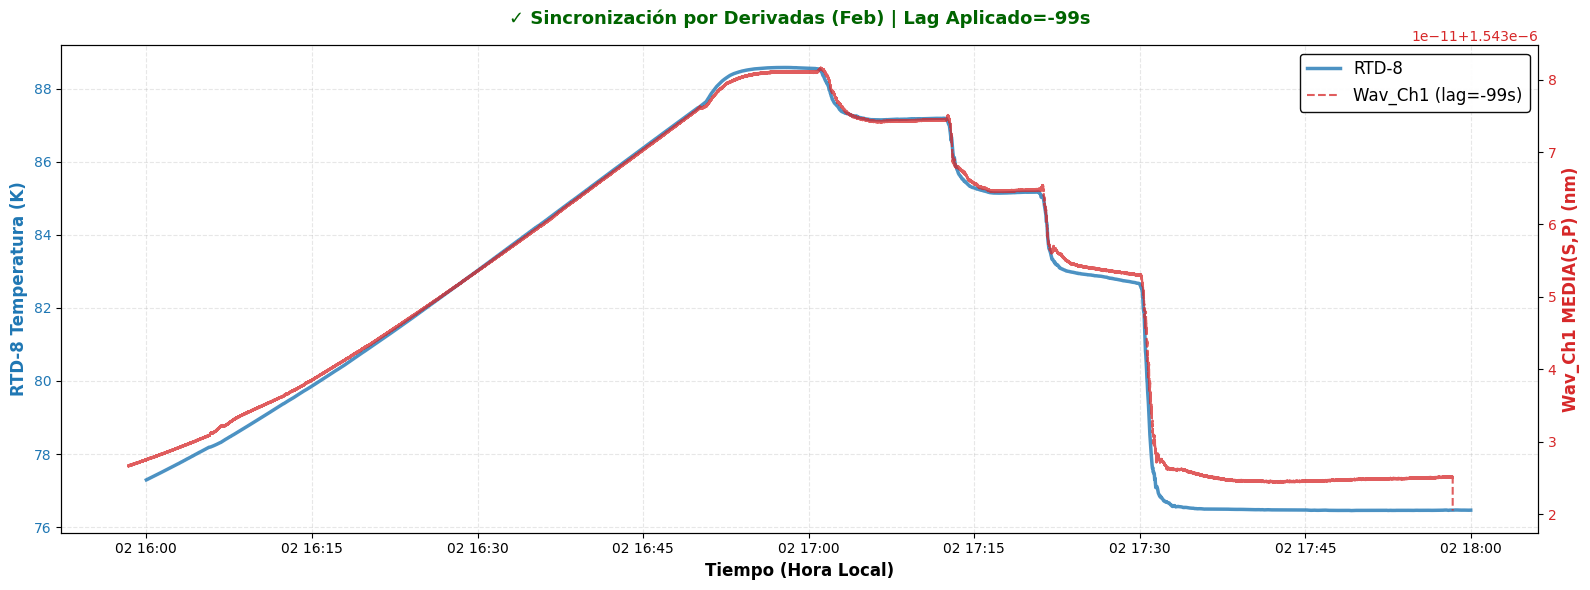

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import correlate, correlation_lags

print("\n" + "="*70)
print("🔬 SINCRONIZACIÓN AVANZADA: CORRELACIÓN DE DERIVADAS (FEBRERO)")
print("="*70)

# Aseguramos variables por si se ejecuta sola
if 'rtd_objetivo' not in locals(): rtd_objetivo = "RTD-8"
if 'active_wav' not in locals(): active_wav = "Wav_Ch1"
if 'pol_start' not in locals(): pol_start = "S"

# Usar RTD-8 como referencia real del análisis
rtd_col = "RTD-8" if "RTD-8" in df_temp_raw.columns else rtd_objetivo

print("""
📋 MÉTODO UTILIZADO:
   1. Interpolación de ambas señales a un grid de 1 segundo (16:00 a 18:00).
   2. CÁLCULO DE DERIVADA: Extraemos la velocidad de cambio punto a punto.
   3. Correlación Cruzada: Busca el instante exacto donde las derivadas (caídas) coinciden.
   4. Infalible frente a zonas planas y desfases masivos.
""")

# Interpolamos ambas señales a grid común
t_min = pd.to_datetime("2026-02-02 16:00:00")
t_max = pd.to_datetime("2026-02-02 18:00:00")
time_grid = pd.date_range(start=t_min, end=t_max, freq="1s")

mask_temp = (df_temp_raw["Time_Datetime"] >= t_min) & (df_temp_raw["Time_Datetime"] <= t_max)
temp_times_num_filt = df_temp_raw.loc[mask_temp, "Time_Datetime"].astype(np.int64).values
grid_times_num = time_grid.astype(np.int64).values

df_peak_filt = df_peak_raw[(df_peak_raw["Time_Datetime"] >= t_min) & 
                            (df_peak_raw["Time_Datetime"] <= t_max)].copy()
df_peak_filt = df_peak_filt.sort_values("Time_Datetime").reset_index(drop=True)

if pol_start.upper() == "S":
    df_peak_filt["pol"] = np.where(np.arange(len(df_peak_filt)) % 2 == 0, "S", "P")
else:
    df_peak_filt["pol"] = np.where(np.arange(len(df_peak_filt)) % 2 == 0, "P", "S")

df_peak_filt["pair_id"] = np.arange(len(df_peak_filt)) // 2
df_peak_pairs = df_peak_filt.pivot_table(
    index="pair_id", columns="pol", values=active_wav, aggfunc="first"
)
df_time_pairs = df_peak_filt.groupby("pair_id", as_index=False)["Time_Datetime"].first()
df_peak_mean_16_18 = df_time_pairs.copy()
df_peak_mean_16_18 = df_peak_mean_16_18.merge(df_peak_pairs, left_on="pair_id", right_index=True, how="left")
df_peak_mean_16_18["wav_mean"] = df_peak_mean_16_18[["S", "P"]].mean(axis=1)
df_peak_mean_16_18 = df_peak_mean_16_18.dropna(subset=["wav_mean"])

peak_times_num_mean = df_peak_mean_16_18["Time_Datetime"].astype(np.int64).values

# Interpolar
temp_interp = np.interp(grid_times_num, temp_times_num_filt, df_temp_raw.loc[mask_temp, rtd_col].values)
peak_interp = np.interp(grid_times_num, peak_times_num_mean, df_peak_mean_16_18["wav_mean"].values)

# ====================================================================
# 🚀 MOTOR DE SINCRONIZACIÓN POR DERIVADAS (INFALIBLE)
# ====================================================================
# Calculamos la diferencia (velocidad de cambio) punto a punto
temp_diff = np.diff(temp_interp)
peak_diff = np.diff(peak_interp)

# Normalizamos las derivadas para comparar formas puras
temp_diff_norm = (temp_diff - np.mean(temp_diff)) / (np.std(temp_diff) + 1e-10)
peak_diff_norm = (peak_diff - np.mean(peak_diff)) / (np.std(peak_diff) + 1e-10)

# Aplicamos la correlación cruzada estricta sobre las derivadas
correlation = correlate(temp_diff_norm, peak_diff_norm, mode="full")
lags = correlation_lags(len(temp_diff_norm), len(peak_diff_norm), mode="full")

# Extraemos el lag que maximiza la coincidencia de la caída
best_lag_final = lags[np.argmax(correlation)]

print(f"\n✅ RESULTADO EXACTO:")
print(f"   Referencia usada: {rtd_col}")
print(f"   Lag detectado en el salto: {best_lag_final} segundos")

# Aplicar corrección
desfase_segundos = int(best_lag_final)
df_peak_mean_16_18["Time_Datetime_Corrected"] = (
    df_peak_mean_16_18["Time_Datetime"] + pd.to_timedelta(desfase_segundos, unit="s")
)

print("\n" + "="*70)
print("📊 VISUALIZACIÓN FINAL: ALINEACIÓN A ESCALA REAL")
print("="*70)

# Obtener rango de datos para plot
mask_temp_range = (df_temp_raw["Time_Datetime"] >= t_min) & (df_temp_raw["Time_Datetime"] <= t_max)
df_temp_range = df_temp_raw[mask_temp_range].copy()

# Gráfico con dual-axis
fig_dual, ax1 = plt.subplots(figsize=(16, 6))

color_temp = "tab:blue"
ax1.set_xlabel("Tiempo (Hora Local)", fontsize=12, fontweight="bold")
ax1.set_ylabel(f"{rtd_col} Temperatura (K)", color=color_temp, fontsize=12, fontweight="bold")
line1 = ax1.plot(df_temp_range["Time_Datetime"], df_temp_range[rtd_col], 
                 color=color_temp, linewidth=2.5, alpha=0.8, label=f"{rtd_col}")
ax1.tick_params(axis="y", labelcolor=color_temp)
ax1.grid(True, alpha=0.3, linestyle="--")

ax2 = ax1.twinx()
color_wav = "tab:red"
ax2.set_ylabel(f"{active_wav} MEDIA(S,P) (nm)", color=color_wav, fontsize=12, fontweight="bold")
line2 = ax2.plot(df_peak_mean_16_18["Time_Datetime_Corrected"], df_peak_mean_16_18["wav_mean"],
                 color=color_wav, linewidth=1.5, alpha=0.75, linestyle="--", 
                 label=f"{active_wav} (lag={desfase_segundos}s)")
ax2.tick_params(axis="y", labelcolor=color_wav)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper right", fontsize=12, framealpha=0.95, edgecolor="black")

ax1.set_title(
    f"✓ Sincronización por Derivadas (Feb) | Lag Aplicado={desfase_segundos}s",
    fontsize=13, fontweight="bold", color="darkgreen", pad=15
)

fig_dual.tight_layout()
plt.show()

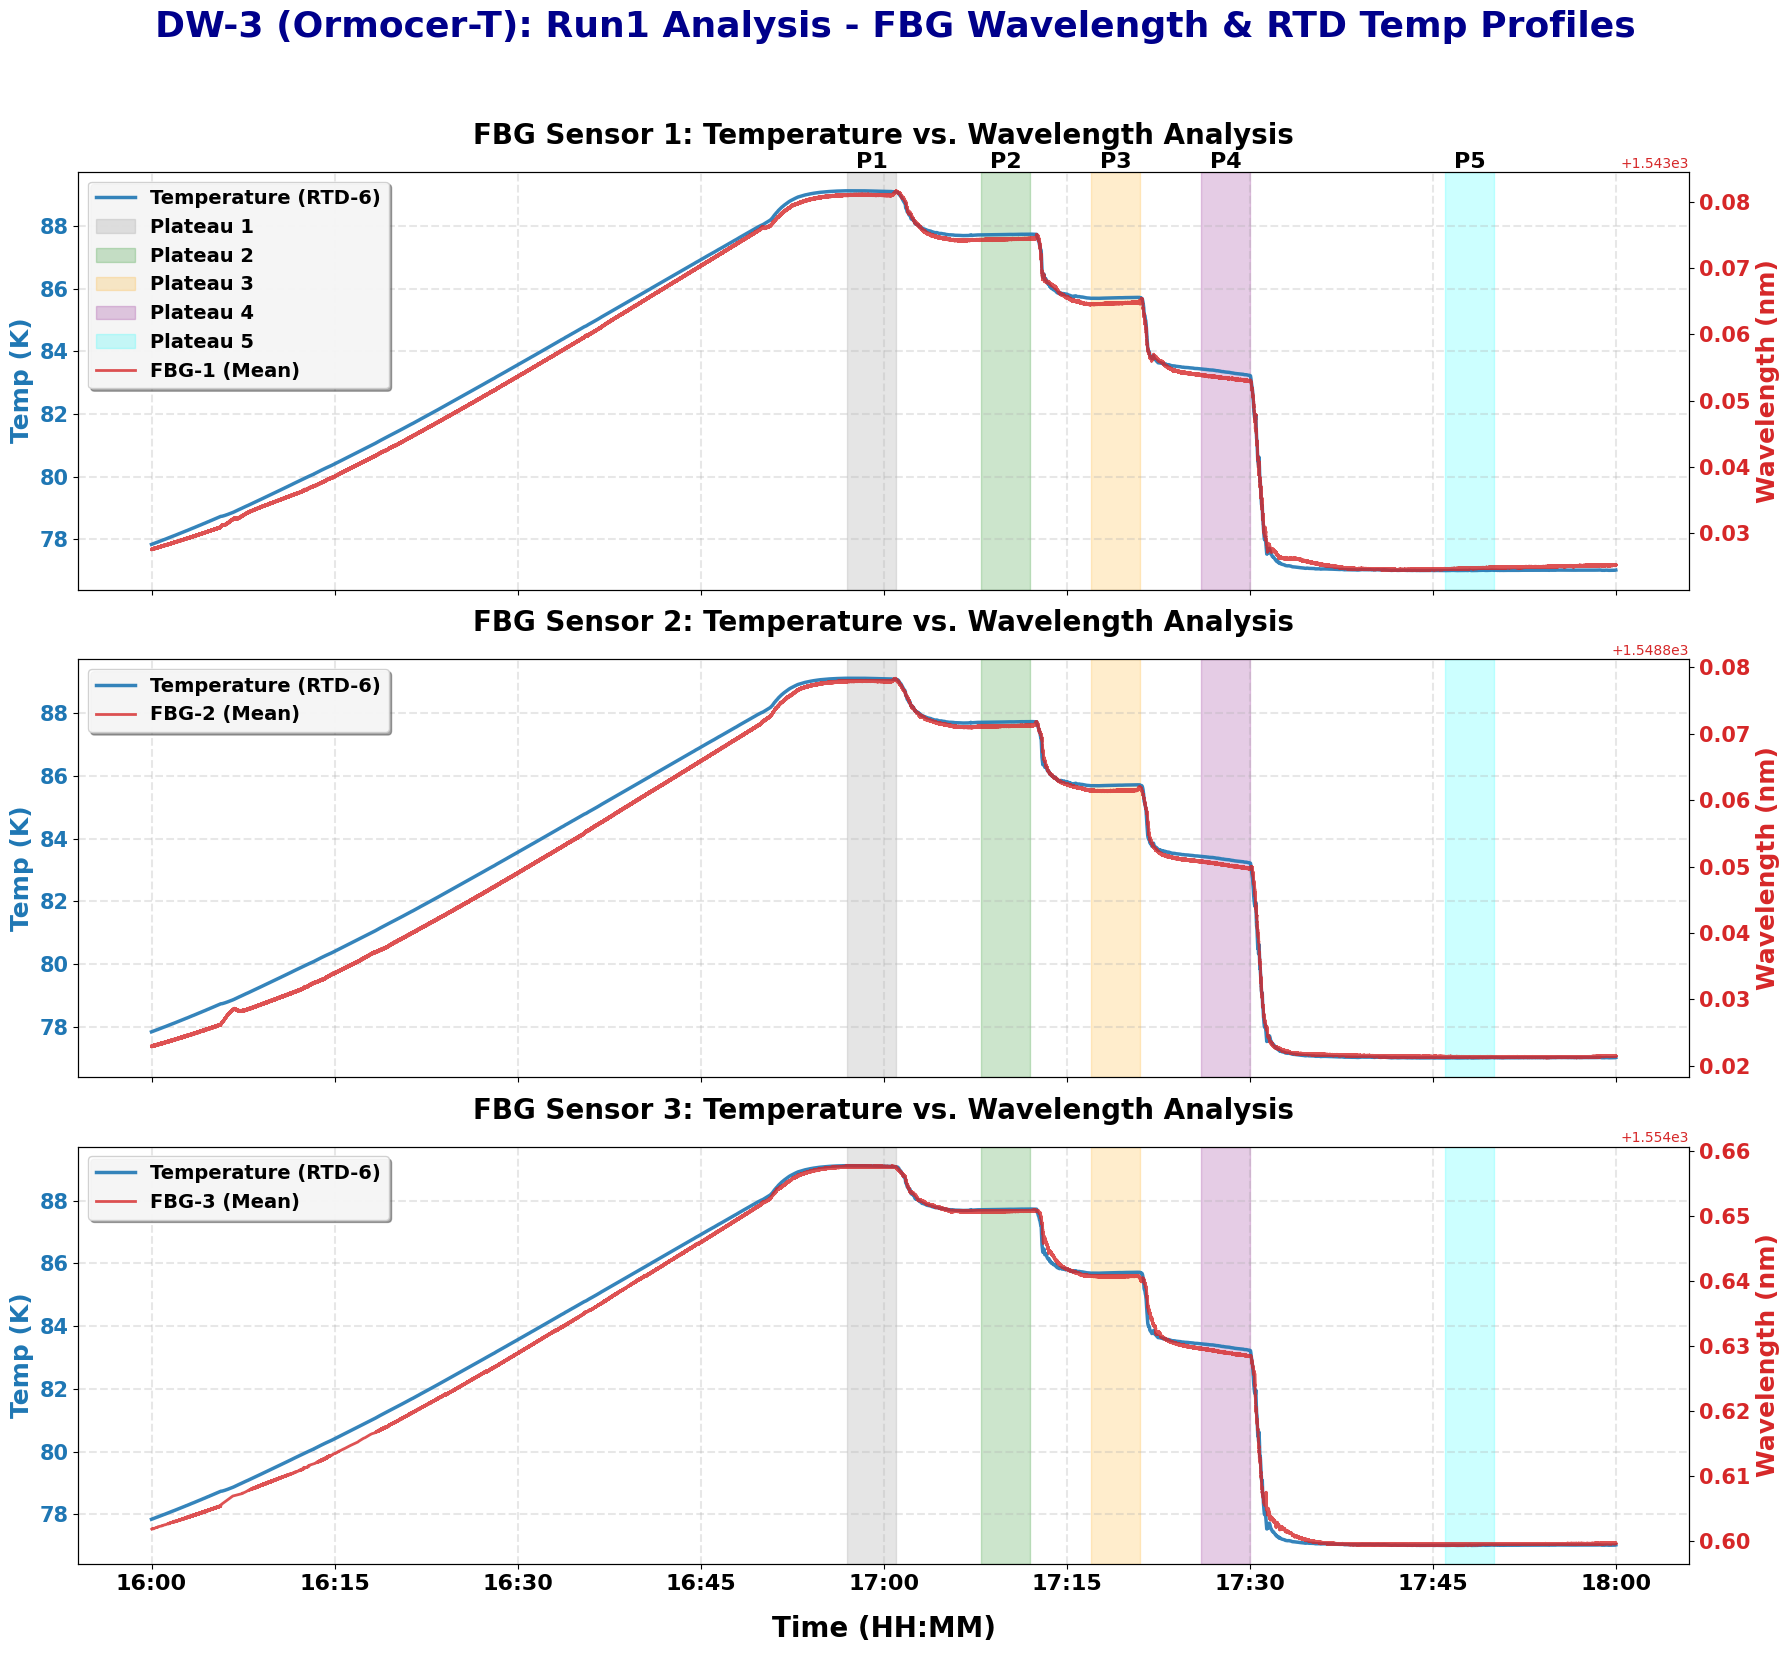

✅ Slide-ready plot generated with enhanced visibility.


In [ ]:
# ============================================================================
# PLOT: Wavelength vs Temperature with Shaded Plateaus (SLIDE OPTIMIZED)
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Configuration
color_temp = 'tab:blue'
color_wav = 'tab:red'
plateau_colors = ['gray', 'green', 'orange', 'purple', 'cyan']

# Aumentamos el tamaño de la figura para que tenga más resolución
fig, axes = plt.subplots(3, 1, figsize=(18, 16), sharex=True)

for idx, sensor_num in enumerate([1, 2, 3]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    if fbg_label not in fbg_mean_data:
        continue
        
    fbg_data_plot = fbg_mean_data[fbg_label]
    ax1 = axes[idx]
    
    # 1. Left Axis: Temperature
    # Aumentamos fontsize a 18 y ponemos negrita extra
    ax1.set_ylabel(f'Temp (K)', fontsize=18, color=color_temp, fontweight='black')
    ax1.plot(times_temp_ref, temp_ref_valid, color=color_temp, linewidth=2.5, alpha=0.9, label='Temperature (RTD-6)')
    
    # Ticks más grandes y en negrita
    ax1.tick_params(axis='y', labelcolor=color_temp, labelsize=15)
    for label in ax1.get_yticklabels():
        label.set_fontweight('bold')
        
    ax1.grid(True, alpha=0.3, linestyle='--', linewidth=1.5)
    
    # 2. Add Shaded Plateaus
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for p_idx, plateau in enumerate(plateau_data):
            p_color = plateau_colors[p_idx % len(plateau_colors)]
            ax1.axvspan(plateau["t0"], plateau["tfin"], 
                        color=p_color, alpha=0.2, 
                        label=f'Plateau {p_idx+1}' if idx == 0 else "")
            
            if idx == 0:
                mid_time = plateau["t0"] + (plateau["tfin"] - plateau["t0"]) / 2
                # Etiquetas de plateau más grandes (P1, P2...)
                ax1.text(mid_time, ax1.get_ylim()[1], f'P{p_idx+1}', 
                         ha='center', va='bottom', fontsize=16, color='black', fontweight='bold')

    # 3. Right Axis: Wavelength
    ax2 = ax1.twinx()
    ax2.set_ylabel('Wavelength (nm)', fontsize=18, color=color_wav, fontweight='black')
    # Línea de wavelength más gruesa para visibilidad
    ax2.plot(fbg_data_plot["timestamps"], fbg_data_plot["wavelength"], 
             color=color_wav, linewidth=2.0, alpha=0.8, 
             label=f'FBG-{sensor_num} (Mean)')
    
    ax2.tick_params(axis='y', labelcolor=color_wav, labelsize=15)
    for label in ax2.get_yticklabels():
        label.set_fontweight('bold')
    
    # Titles de cada subplot más grandes
    ax1.set_title(f'FBG Sensor {sensor_num}: Temperature vs. Wavelength Analysis', 
                  fontsize=20, pad=20, fontweight='bold', color='black')
    
    # Leyendas más legibles y con sombra para destacar
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    leg = ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', 
                     frameon=True, framealpha=0.9, fontsize=14, shadow=True)
    plt.setp(leg.get_texts(), fontweight='bold')

# Format X-Axis (Time)
axes[-1].set_xlabel('Time (HH:MM)', fontsize=20, fontweight='black', labelpad=15)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Ticks del eje X más grandes
for label in axes[-1].get_xticklabels():
    label.set_rotation(0) # He puesto 0 en vez de 45 para que sea más fácil de leer en slide
    label.set_ha('center')
    label.set_fontsize(16)
    label.set_fontweight('bold')

# Título Global GIGANTE para la slide
plt.suptitle('DW-3 (Ormocer-T): Run1 Analysis - FBG Wavelength & RTD Temp Profiles', 
             fontsize=26, y=1.03, fontweight='black', color='darkblue')

plt.tight_layout()
plt.show()

print("✅ Slide-ready plot generated with enhanced visibility.")

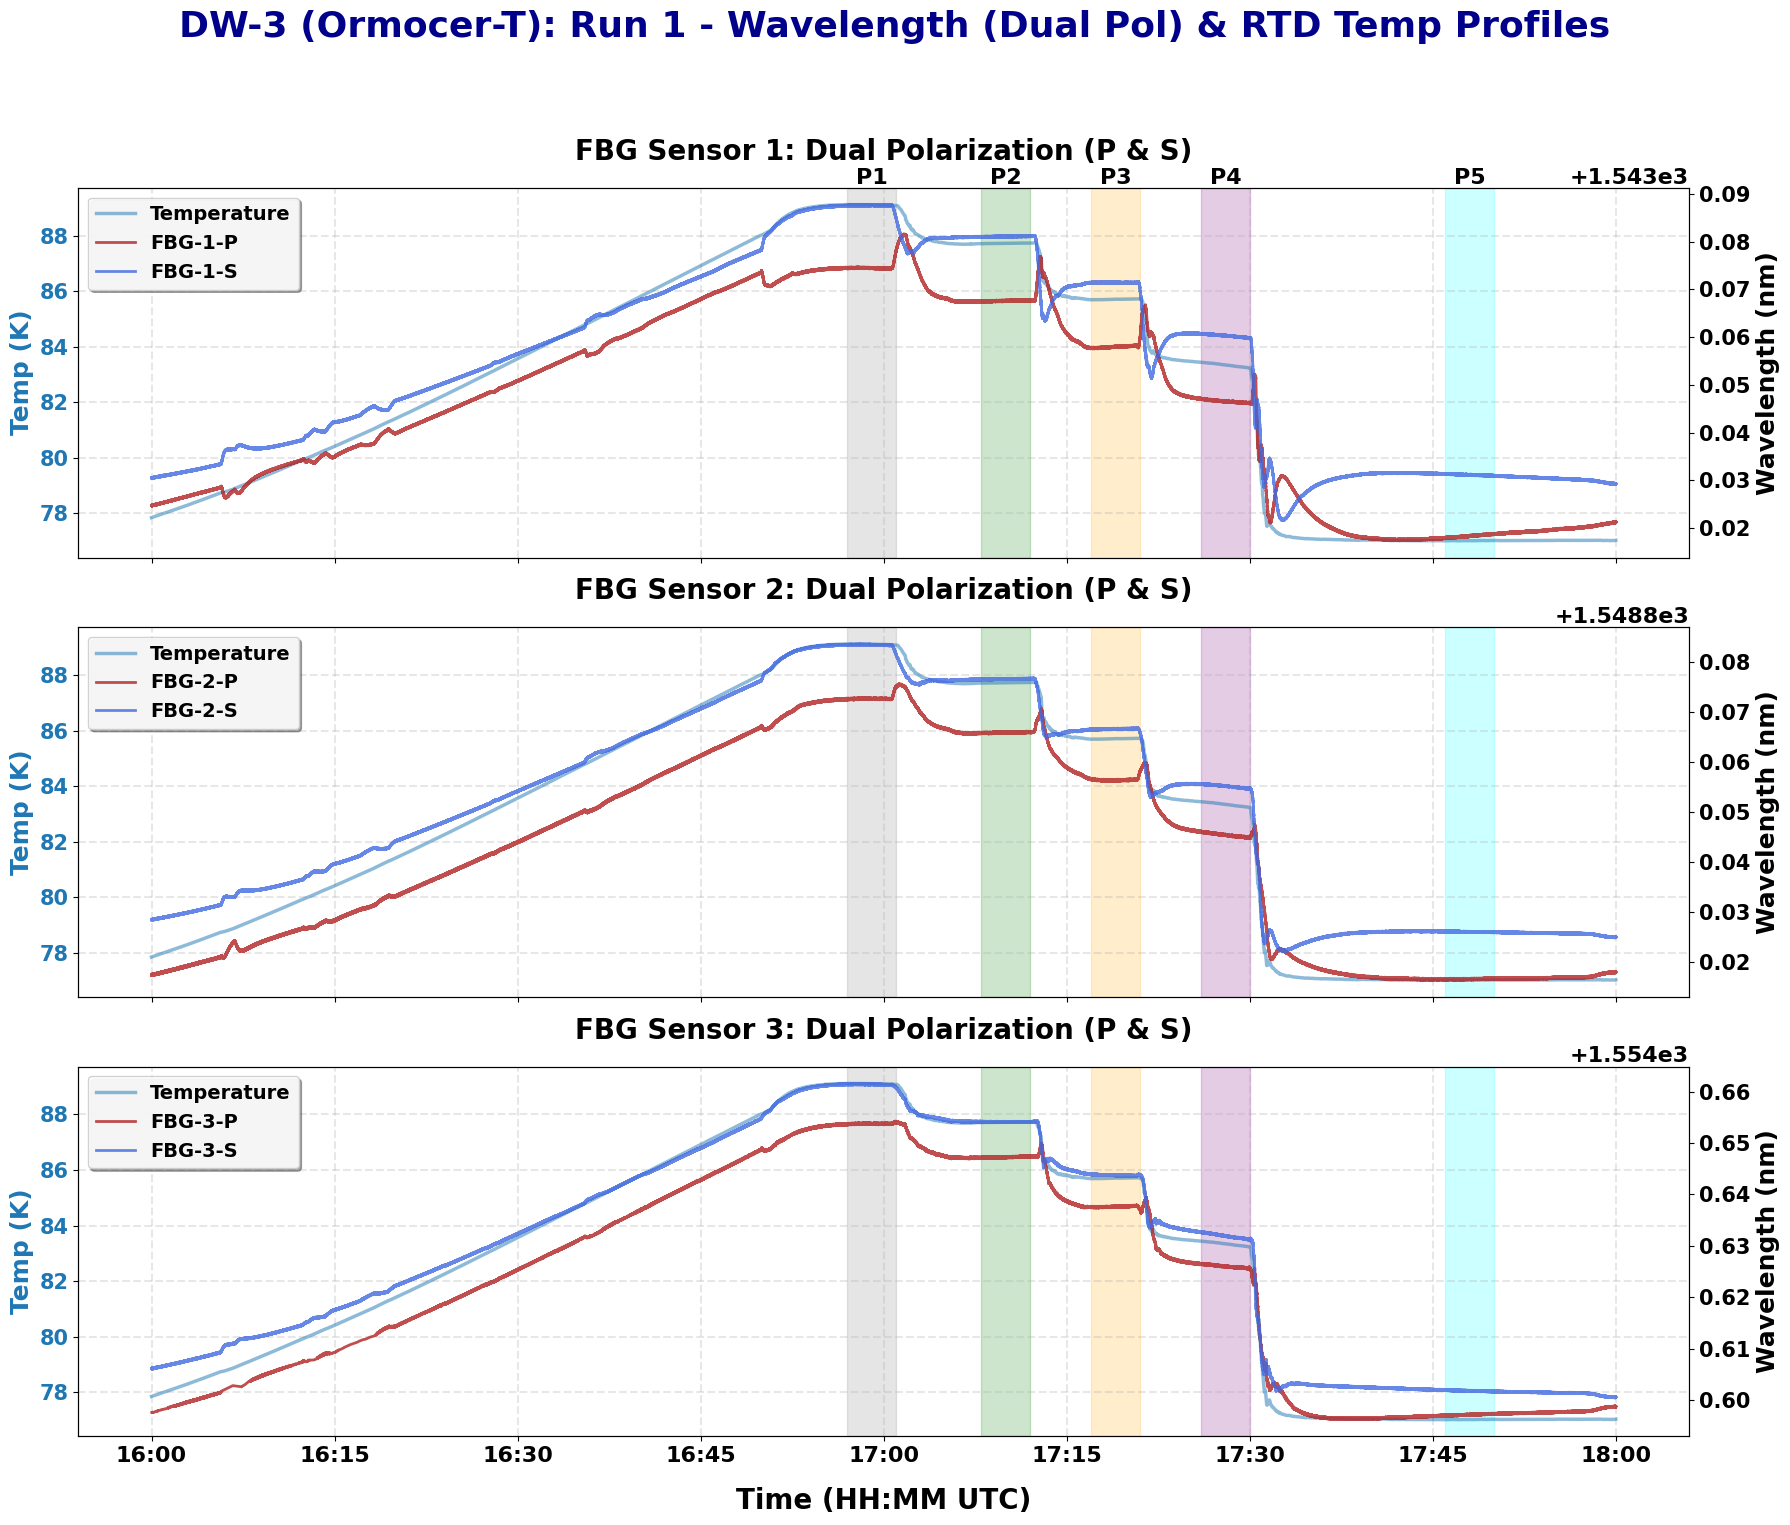

In [ ]:
# ============================================================================
# PLOT: Dual Polarization (P & S) vs Temp (SLIDE OPTIMIZED & FIXED AXIS OFFSET)
# Fiber: DW-3 (Ormocer-T) | Run 1 | 2026-02-02
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

# Configuration
color_temp = 'tab:blue'
color_pol_p = 'firebrick'   
color_pol_s = 'royalblue'   
plateau_colors = ['gray', 'green', 'orange', 'purple', 'cyan']

fig, axes = plt.subplots(3, 1, figsize=(18, 16), sharex=True)

for idx, sensor_num in enumerate([1, 2, 3]):
    label_p = f"FBG-{sensor_num}-P"
    label_s = f"FBG-{sensor_num}-S"
    
    if label_p not in fbg_filtered_data or label_s not in fbg_filtered_data:
        continue
        
    data_p = fbg_filtered_data[label_p]
    data_s = fbg_filtered_data[label_s]
    ax1 = axes[idx]
    
    # 1. Left Axis: Temperature
    ax1.set_ylabel(f'Temp (K)', fontsize=18, color=color_temp, fontweight='black')
    ax1.plot(times_temp_ref, temp_ref_valid, color=color_temp, linewidth=2.5, alpha=0.5, label='Temperature')
    ax1.tick_params(axis='y', labelcolor=color_temp, labelsize=15)
    for label in ax1.get_yticklabels():
        label.set_fontweight('bold')
    ax1.grid(True, alpha=0.3, linestyle='--', linewidth=1.5)
    
    # 2. Add Shaded Plateaus
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for p_idx, plateau in enumerate(plateau_data):
            p_color = plateau_colors[p_idx % len(plateau_colors)]
            ax1.axvspan(plateau["t0"], plateau["tfin"], color=p_color, alpha=0.2)
            if idx == 0:
                mid_time = plateau["t0"] + (plateau["tfin"] - plateau["t0"]) / 2
                ax1.text(mid_time, ax1.get_ylim()[1], f'P{p_idx+1}', 
                         ha='center', va='bottom', fontsize=16, fontweight='bold', color='black')

    # 3. Right Axis: Wavelength (P & S)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Wavelength (nm)', fontsize=18, color='black', fontweight='black')
    
    ax2.plot(data_p["timestamps"], data_p["wavelength"], 
             color=color_pol_p, linewidth=2.0, alpha=0.8, label=f'FBG-{sensor_num}-P')
    ax2.plot(data_s["timestamps"], data_s["wavelength"], 
             color=color_pol_s, linewidth=2.0, alpha=0.8, label=f'FBG-{sensor_num}-S')
    
    ax2.tick_params(axis='y', labelcolor='black', labelsize=15)
    
    # --- FIX: AJUSTE DEL FACTOR COMÚN (OFFSET/SCIENTIFIC NOTATION) ---
    # Esto asegura que el "1.55" o el "+1e3" se vea grande y en negrita
    y_formatter = ax2.yaxis.get_major_formatter()
    ax2.yaxis.set_major_formatter(ticker.ScalarFormatter(useOffset=True))
    ax2.yaxis.get_offset_text().set_fontsize(16)
    ax2.yaxis.get_offset_text().set_fontweight('bold')
    
    for label in ax2.get_yticklabels():
        label.set_fontweight('bold')
    
    # Estilo de Subplots
    ax1.set_title(f'FBG Sensor {sensor_num}: Dual Polarization (P & S)', 
                  fontsize=20, pad=20, fontweight='bold')
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    leg = ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', 
                     frameon=True, framealpha=0.9, fontsize=14, shadow=True)
    plt.setp(leg.get_texts(), fontweight='bold')

# Format X-Axis
axes[-1].set_xlabel('Time (HH:MM UTC)', fontsize=20, fontweight='black', labelpad=15)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

for label in axes[-1].get_xticklabels():
    label.set_fontsize(16)
    label.set_fontweight('bold')

# Global Title
plt.suptitle('DW-3 (Ormocer-T): Run 1 - Wavelength (Dual Pol) & RTD Temp Profiles', 
             fontsize=26, y=0.98, fontweight='black', color='darkblue')

plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()

### 6.4 Calcular Sensibilidad por Plateaus

Calcula la media y std de wavelength en cada plateau para cada sensor FBG.

In [ ]:
# Calcular media y std de wavelength por plateau para cada sensor
plateau_sensitivity_data = {}

for fbg_label, fbg_data in fbg_mean_data.items():
    sensor_num = fbg_data["sensor_num"]
    fbg_times = fbg_data["timestamps"]
    fbg_wav = fbg_data["wavelength"]
    
    plateau_wav_stats = []
    
    for plateau in plateau_data:
        # Máscara para datos de wavelength en este plateau
        mask_wav_plateau = (fbg_times >= plateau["t0"]) & (fbg_times <= plateau["tfin"])
        wav_plateau = fbg_wav[mask_wav_plateau]
        
        if len(wav_plateau) > 0:
            wav_mean = np.mean(wav_plateau)
            wav_std = np.std(wav_plateau)
            
            plateau_wav_stats.append({
                "name": plateau["name"],
                "temp_mean": plateau["temp_mean"],
                "temp_std": plateau["temp_std"],
                "wav_mean": wav_mean,
                "wav_std": wav_std,
                "n_wav_points": len(wav_plateau)
            })
    
    plateau_sensitivity_data[fbg_label] = plateau_wav_stats

print("✅ Estadísticas de wavelength calculadas por plateau")
print("\nResumen por sensor:")
print("="*80)
for fbg_label in fbg_mean_data.keys():
    sensor_num = fbg_mean_data[fbg_label]["sensor_num"]
    n_plateaus = len(plateau_sensitivity_data[fbg_label])
    print(f"FBG-{sensor_num}: {n_plateaus} plateaus procesados")

✅ Estadísticas de wavelength calculadas por plateau

Resumen por sensor:
FBG-1: 5 plateaus procesados
FBG-2: 5 plateaus procesados
FBG-3: 5 plateaus procesados


### 6.5 Visualizar Sensibilidad (Temp vs Wavelength con barras de error)

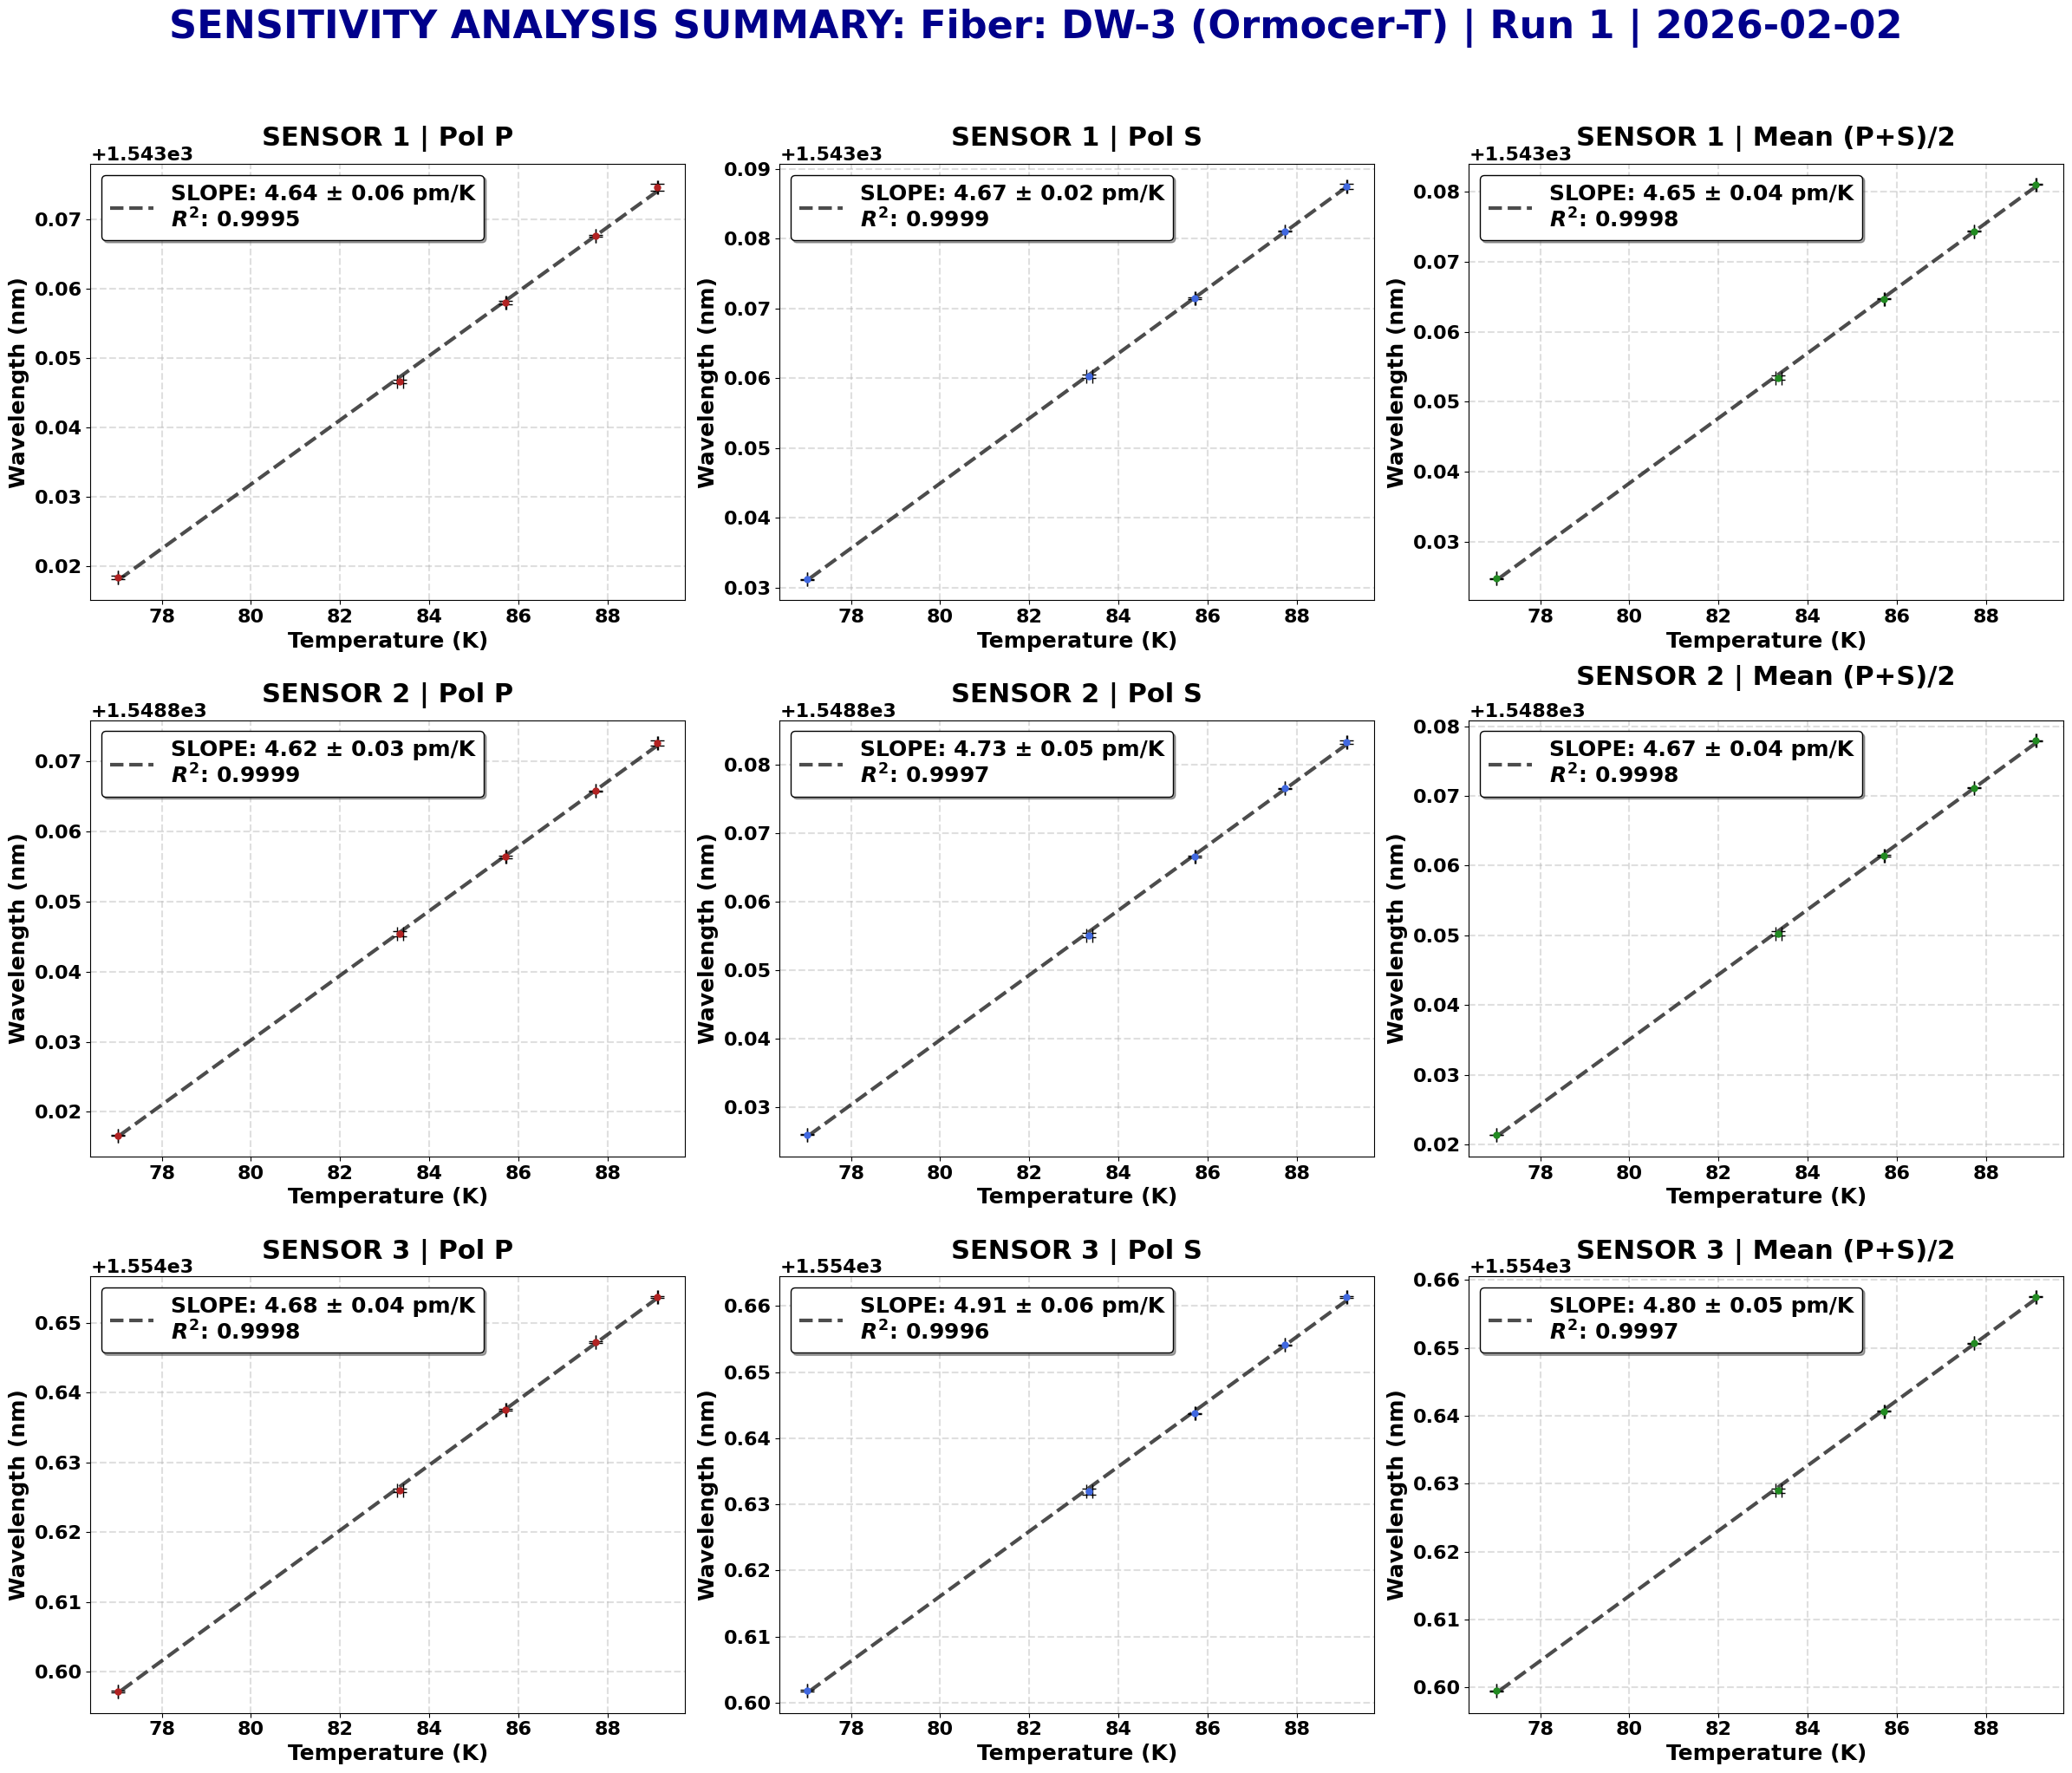


                         SENSITIVITY SUMMARY TABLE: FIBER DW-3 (Run 1)                         
Sensor   | Type            | Slope (pm/K)       | Error (pm/K)    | R²      
-----------------------------------------------------------------------------------------------
S1       | Pol P           |        4.643       |        0.062    | 0.9995
S1       | Pol S           |        4.666       |        0.020    | 0.9999
S1       | Mean (P+S)/2    |        4.654       |        0.040    | 0.9998
S2       | Pol P           |        4.619       |        0.032    | 0.9999
S2       | Pol S           |        4.727       |        0.047    | 0.9997
S2       | Mean (P+S)/2    |        4.673       |        0.038    | 0.9998
S3       | Pol P           |        4.684       |        0.038    | 0.9998
S3       | Pol S           |        4.911       |        0.057    | 0.9996
S3       | Mean (P+S)/2    |        4.797       |        0.046    | 0.9997


In [ ]:
# ============================================================================
# FINAL SENSITIVITY ANALYSIS: Fiber DW-3 | Run 1 | SINGLE HIGH-VISIBILITY FIGURE
# ============================================================================

import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import matplotlib.ticker as ticker

# Estilo global para máxima visibilidad en proyector
plt.rcParams.update({'font.weight': 'bold', 'axes.labelweight': 'bold'})

# Estructura para guardar resultados
summary_results = []
fiber_info = "Fiber: DW-3 (Ormocer-T) | Run 1 | 2026-02-02"

# --- CREAMOS UNA SOLA FIGURA (3 Sensores x 3 Tipos = 9 Subplots o 3x3) ---
# He optado por una matriz 3x3 para que cada sensor tenga su fila
fig, axes = plt.subplots(3, 3, figsize=(24, 20))

for s_idx, sensor_num in enumerate([1, 2, 3]):
    plot_configs = [
        {"key": f"FBG-{sensor_num}-P", "title": "Pol P", "color": "firebrick"},
        {"key": f"FBG-{sensor_num}-S", "title": "Pol S", "color": "royalblue"},
        {"key": f"FBG-{sensor_num}-Mean", "title": "Mean (P+S)/2", "color": "forestgreen"}
    ]

    for p_idx, config in enumerate(plot_configs):
        ax = axes[s_idx, p_idx]
        label = config["key"]
        
        t_means, t_stds, w_means, w_stds = [], [], [], []
        
        if 'plateau_data' in globals() and len(plateau_data) > 0:
            for p in plateau_data:
                t_means.append(p["temp_mean"])
                t_stds.append(p["temp_std"])
                source = fbg_mean_data if "Mean" in label else fbg_filtered_data
                
                if label in source:
                    mask = (source[label]["timestamps"] >= p["t0"]) & \
                           (source[label]["timestamps"] <= p["tfin"])
                    wav_data = source[label]["wavelength"][mask]
                    if len(wav_data) > 0:
                        w_means.append(np.mean(wav_data)); w_stds.append(np.std(wav_data))
                    else:
                        w_means.append(np.nan); w_stds.append(np.nan)

            x = np.array(t_means); y = np.array(w_means)
            x_err = np.array(t_stds); y_err = np.array(w_stds)
            mask_valid = ~np.isnan(x) & ~np.isnan(y)
            x, y, x_err, y_err = x[mask_valid], y[mask_valid], x_err[mask_valid], y_err[mask_valid]

            if len(x) > 1:
                slope, intercept, r_val, p_val, std_err = stats.linregress(x, y)
                slope_pm, err_pm = slope * 1e3, std_err * 1e3
                
                summary_results.append({
                    "Sensor": f"S{sensor_num}", "Type": config["title"],
                    "Slope": slope_pm, "Error": err_pm, "R2": r_val**2
                })

                # --- PLOT DE ALTA VISIBILIDAD ---
                # Puntos y barras de error más gruesas
                ax.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='o', color=config["color"], 
                            ecolor='black', elinewidth=2.5, capsize=6, markersize=5,
                            label='Experimental Data')
                
                # Línea de ajuste más marcada
                ax.plot(x, slope*x + intercept, color='black', linestyle='--', linewidth=3, alpha=0.7)

                # --- LEYENDA GIGANTE CON LA SLOPE ---
                slope_label = f"SLOPE: {slope_pm:.2f} ± {err_pm:.2f} pm/K\n$R^2$: {r_val**2:.4f}"
                leg = ax.legend([slope_label], loc='upper left', fontsize=18, 
                                 frameon=True, shadow=True, facecolor='white', edgecolor='black')
                plt.setp(leg.get_texts(), fontweight='black')

                # Estilo de ejes (Grande y Negrita)
                ax.set_title(f"SENSOR {sensor_num} | {config['title']}", fontsize=22, fontweight='black', pad=15)
                ax.set_xlabel("Temperature (K)", fontsize=18, fontweight='bold')
                ax.set_ylabel("Wavelength (nm)", fontsize=18, fontweight='bold')
                
                # Números de los ejes grandes
                ax.tick_params(axis='both', which='major', labelsize=16)
                for label_tick in ax.get_xticklabels() + ax.get_yticklabels():
                    label_tick.set_fontweight('bold')

                # Factor común (Offset) grande
                ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useOffset=True))
                ax.yaxis.get_offset_text().set_fontsize(16)
                ax.yaxis.get_offset_text().set_fontweight('bold')
                
                ax.grid(True, alpha=0.4, linestyle='--', linewidth=1.5)

# Título Global para la Slide
plt.suptitle(f"SENSITIVITY ANALYSIS SUMMARY: {fiber_info}", 
             fontsize=32, y=1.02, fontweight='black', color='darkblue')

plt.tight_layout()
plt.show()

# ============================================================================
# FINAL SUMMARY TABLE (IMPRESIÓN EN CONSOLA)
# ============================================================================
print("\n" + "="*95)
print(f"{'SENSITIVITY SUMMARY TABLE: FIBER DW-3 (Run 1)':^95}")
print("="*95)
print(f"{'Sensor':<8} | {'Type':<15} | {'Slope (pm/K)':<18} | {'Error (pm/K)':<15} | {'R²':<8}")
print("-" * 95)
for res in summary_results:
    print(f"{res['Sensor']:<8} | {res['Type']:<15} | {res['Slope']:>12.3f}       | {res['Error']:>12.3f}    | {res['R2']:.4f}")
print("="*95)

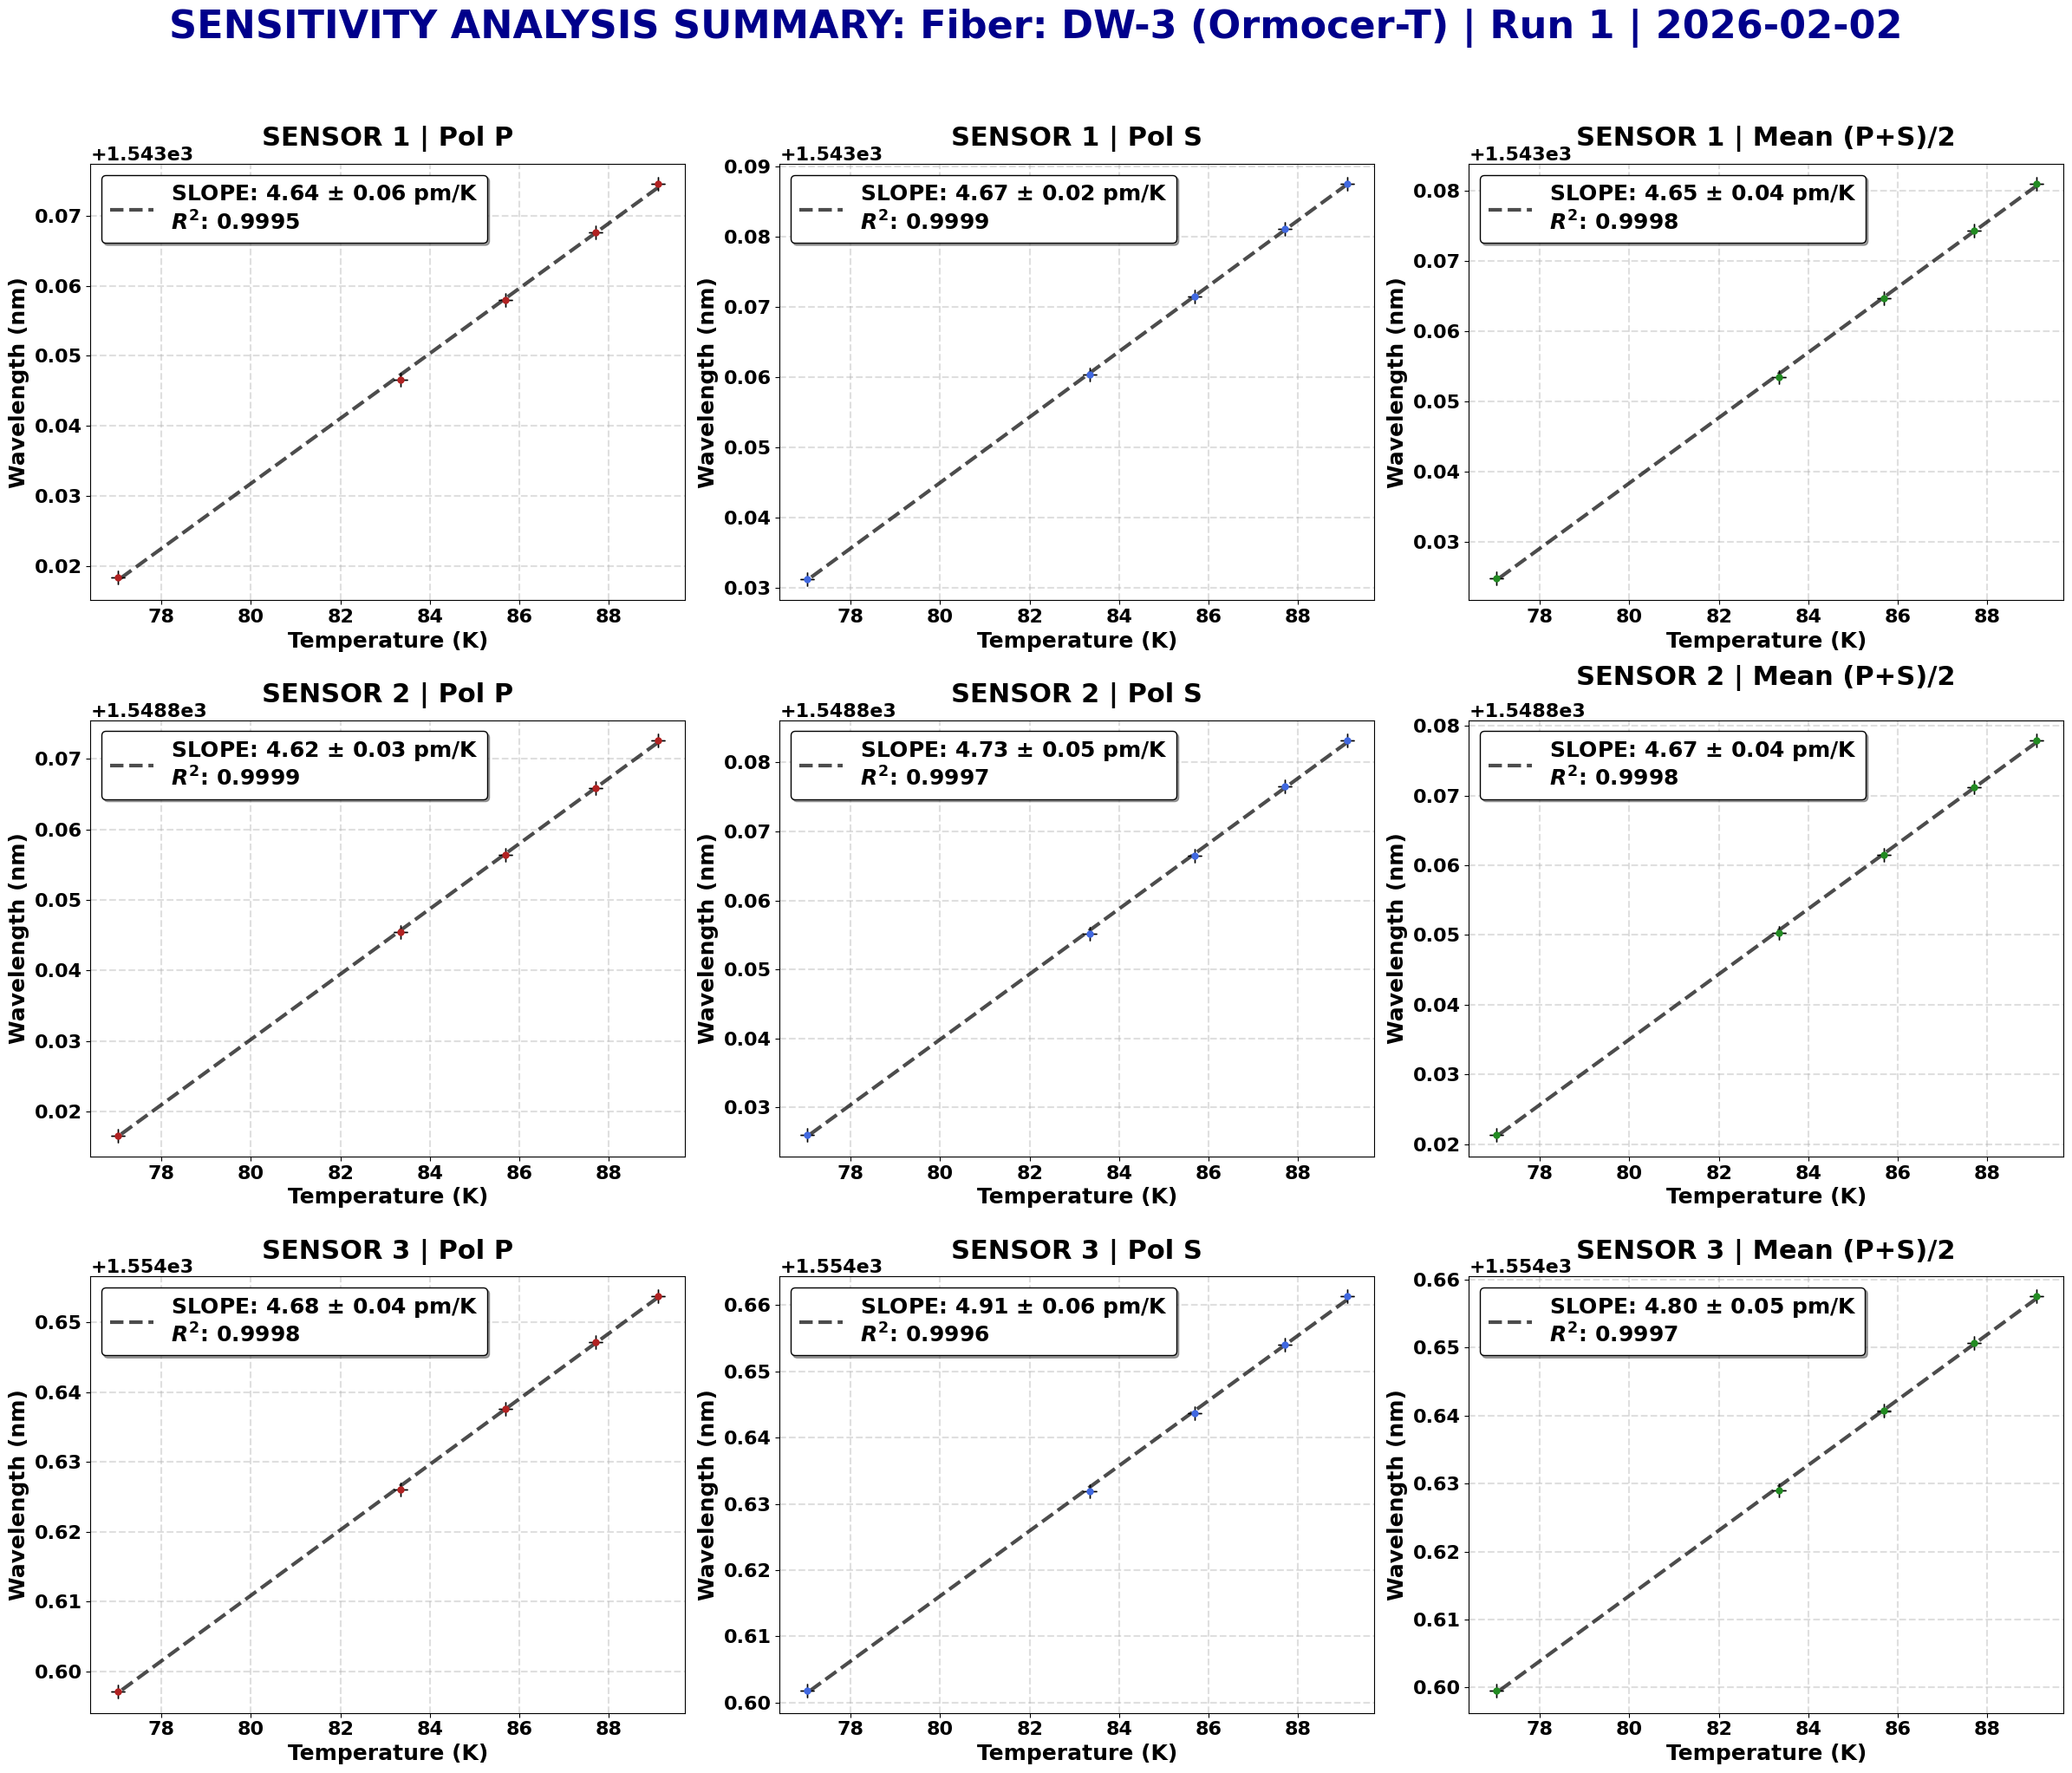

In [ ]:
# ============================================================================
# FINAL SENSITIVITY ANALYSIS: Fiber DW-3 | Run 1 | SINGLE HIGH-VISIBILITY FIGURE
# ============================================================================

import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import matplotlib.ticker as ticker

# Estilo global para máxima visibilidad en proyector
plt.rcParams.update({'font.weight': 'bold', 'axes.labelweight': 'bold'})

summary_results = []
fiber_info = "Fiber: DW-3 (Ormocer-T) | Run 1 | 2026-02-02"

fig, axes = plt.subplots(3, 3, figsize=(24, 20))

for s_idx, sensor_num in enumerate([1, 2, 3]):
    plot_configs = [
        {"key": f"FBG-{sensor_num}-P", "title": "Pol P", "color": "firebrick"},
        {"key": f"FBG-{sensor_num}-S", "title": "Pol S", "color": "royalblue"},
        {"key": f"FBG-{sensor_num}-Mean", "title": "Mean (P+S)/2", "color": "forestgreen"}
    ]

    for p_idx, config in enumerate(plot_configs):
        ax = axes[s_idx, p_idx]
        label = config["key"]
        
        # Aquí guardaremos las medias y sus correspondientes SEM (Error de la media)
        t_means, t_sems, w_means, w_sems = [], [], [], []
        
        if 'plateau_data' in globals() and len(plateau_data) > 0:
            for p in plateau_data:
                source = fbg_mean_data if "Mean" in label else fbg_filtered_data
                
                if label in source:
                    mask = (source[label]["timestamps"] >= p["t0"]) & \
                           (source[label]["timestamps"] <= p["tfin"])
                    wav_data = source[label]["wavelength"][mask]
                    
                    if len(wav_data) > 0:
                        # Número de muestras en este plateau
                        n_samples = len(wav_data)
                        
                        # Guardamos las medias de X e Y
                        t_means.append(p["temp_mean"])
                        w_means.append(np.mean(wav_data))
                        
                        # --- NUEVO: CÁLCULO DEL ERROR DE LA MEDIA (SEM) ---
                        # Para longitud de onda usamos stats.sem de Scipy
                        w_sems.append(stats.sem(wav_data))
                        
                        # Para temperatura, calculamos el SEM usando la desviación estándar y la raíz de N
                        # (Asumiendo que el sensor de temperatura y el FBG miden en ventanas temporales equivalentes)
                        t_sems.append(p["temp_std"] / np.sqrt(n_samples))
                    else:
                        w_means.append(np.nan); w_sems.append(np.nan)
                        t_means.append(np.nan); t_sems.append(np.nan)

            x = np.array(t_means); y = np.array(w_means)
            x_err = np.array(t_sems); y_err = np.array(w_sems)  # <--- Ahora usamos los SEM
            mask_valid = ~np.isnan(x) & ~np.isnan(y)
            x, y, x_err, y_err = x[mask_valid], y[mask_valid], x_err[mask_valid], y_err[mask_valid]

            if len(x) > 1:
                slope, intercept, r_val, p_val, std_err = stats.linregress(x, y)
                slope_pm, err_pm = slope * 1e3, std_err * 1e3
                
                summary_results.append({
                    "Sensor": f"S{sensor_num}", "Type": config["title"],
                    "Slope": slope_pm, "Error": err_pm, "R2": r_val**2
                })

                # --- PLOT DE ALTA VISIBILIDAD (Con barras de error SEM) ---
                ax.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='o', color=config["color"], 
                            ecolor='black', elinewidth=2.5, capsize=6, markersize=5,
                            label='Experimental Data')
                
                ax.plot(x, slope*x + intercept, color='black', linestyle='--', linewidth=3, alpha=0.7)

                # --- LEYENDA GIGANTE CON LA SLOPE ---
                slope_label = f"SLOPE: {slope_pm:.2f} $\pm$ {err_pm:.2f} pm/K\n$R^2$: {r_val**2:.4f}"
                leg = ax.legend([slope_label], loc='upper left', fontsize=18, 
                                 frameon=True, shadow=True, facecolor='white', edgecolor='black')
                plt.setp(leg.get_texts(), fontweight='black')

                ax.set_title(f"SENSOR {sensor_num} | {config['title']}", fontsize=22, fontweight='black', pad=15)
                ax.set_xlabel("Temperature (K)", fontsize=18, fontweight='bold')
                ax.set_ylabel("Wavelength (nm)", fontsize=18, fontweight='bold')
                
                ax.tick_params(axis='both', which='major', labelsize=16)
                for label_tick in ax.get_xticklabels() + ax.get_yticklabels():
                    label_tick.set_fontweight('bold')

                ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useOffset=True))
                ax.yaxis.get_offset_text().set_fontsize(16)
                ax.yaxis.get_offset_text().set_fontweight('bold')
                
                ax.grid(True, alpha=0.4, linestyle='--', linewidth=1.5)

plt.suptitle(f"SENSITIVITY ANALYSIS SUMMARY: {fiber_info}", 
             fontsize=32, y=1.02, fontweight='black', color='darkblue')

plt.tight_layout()
plt.show()

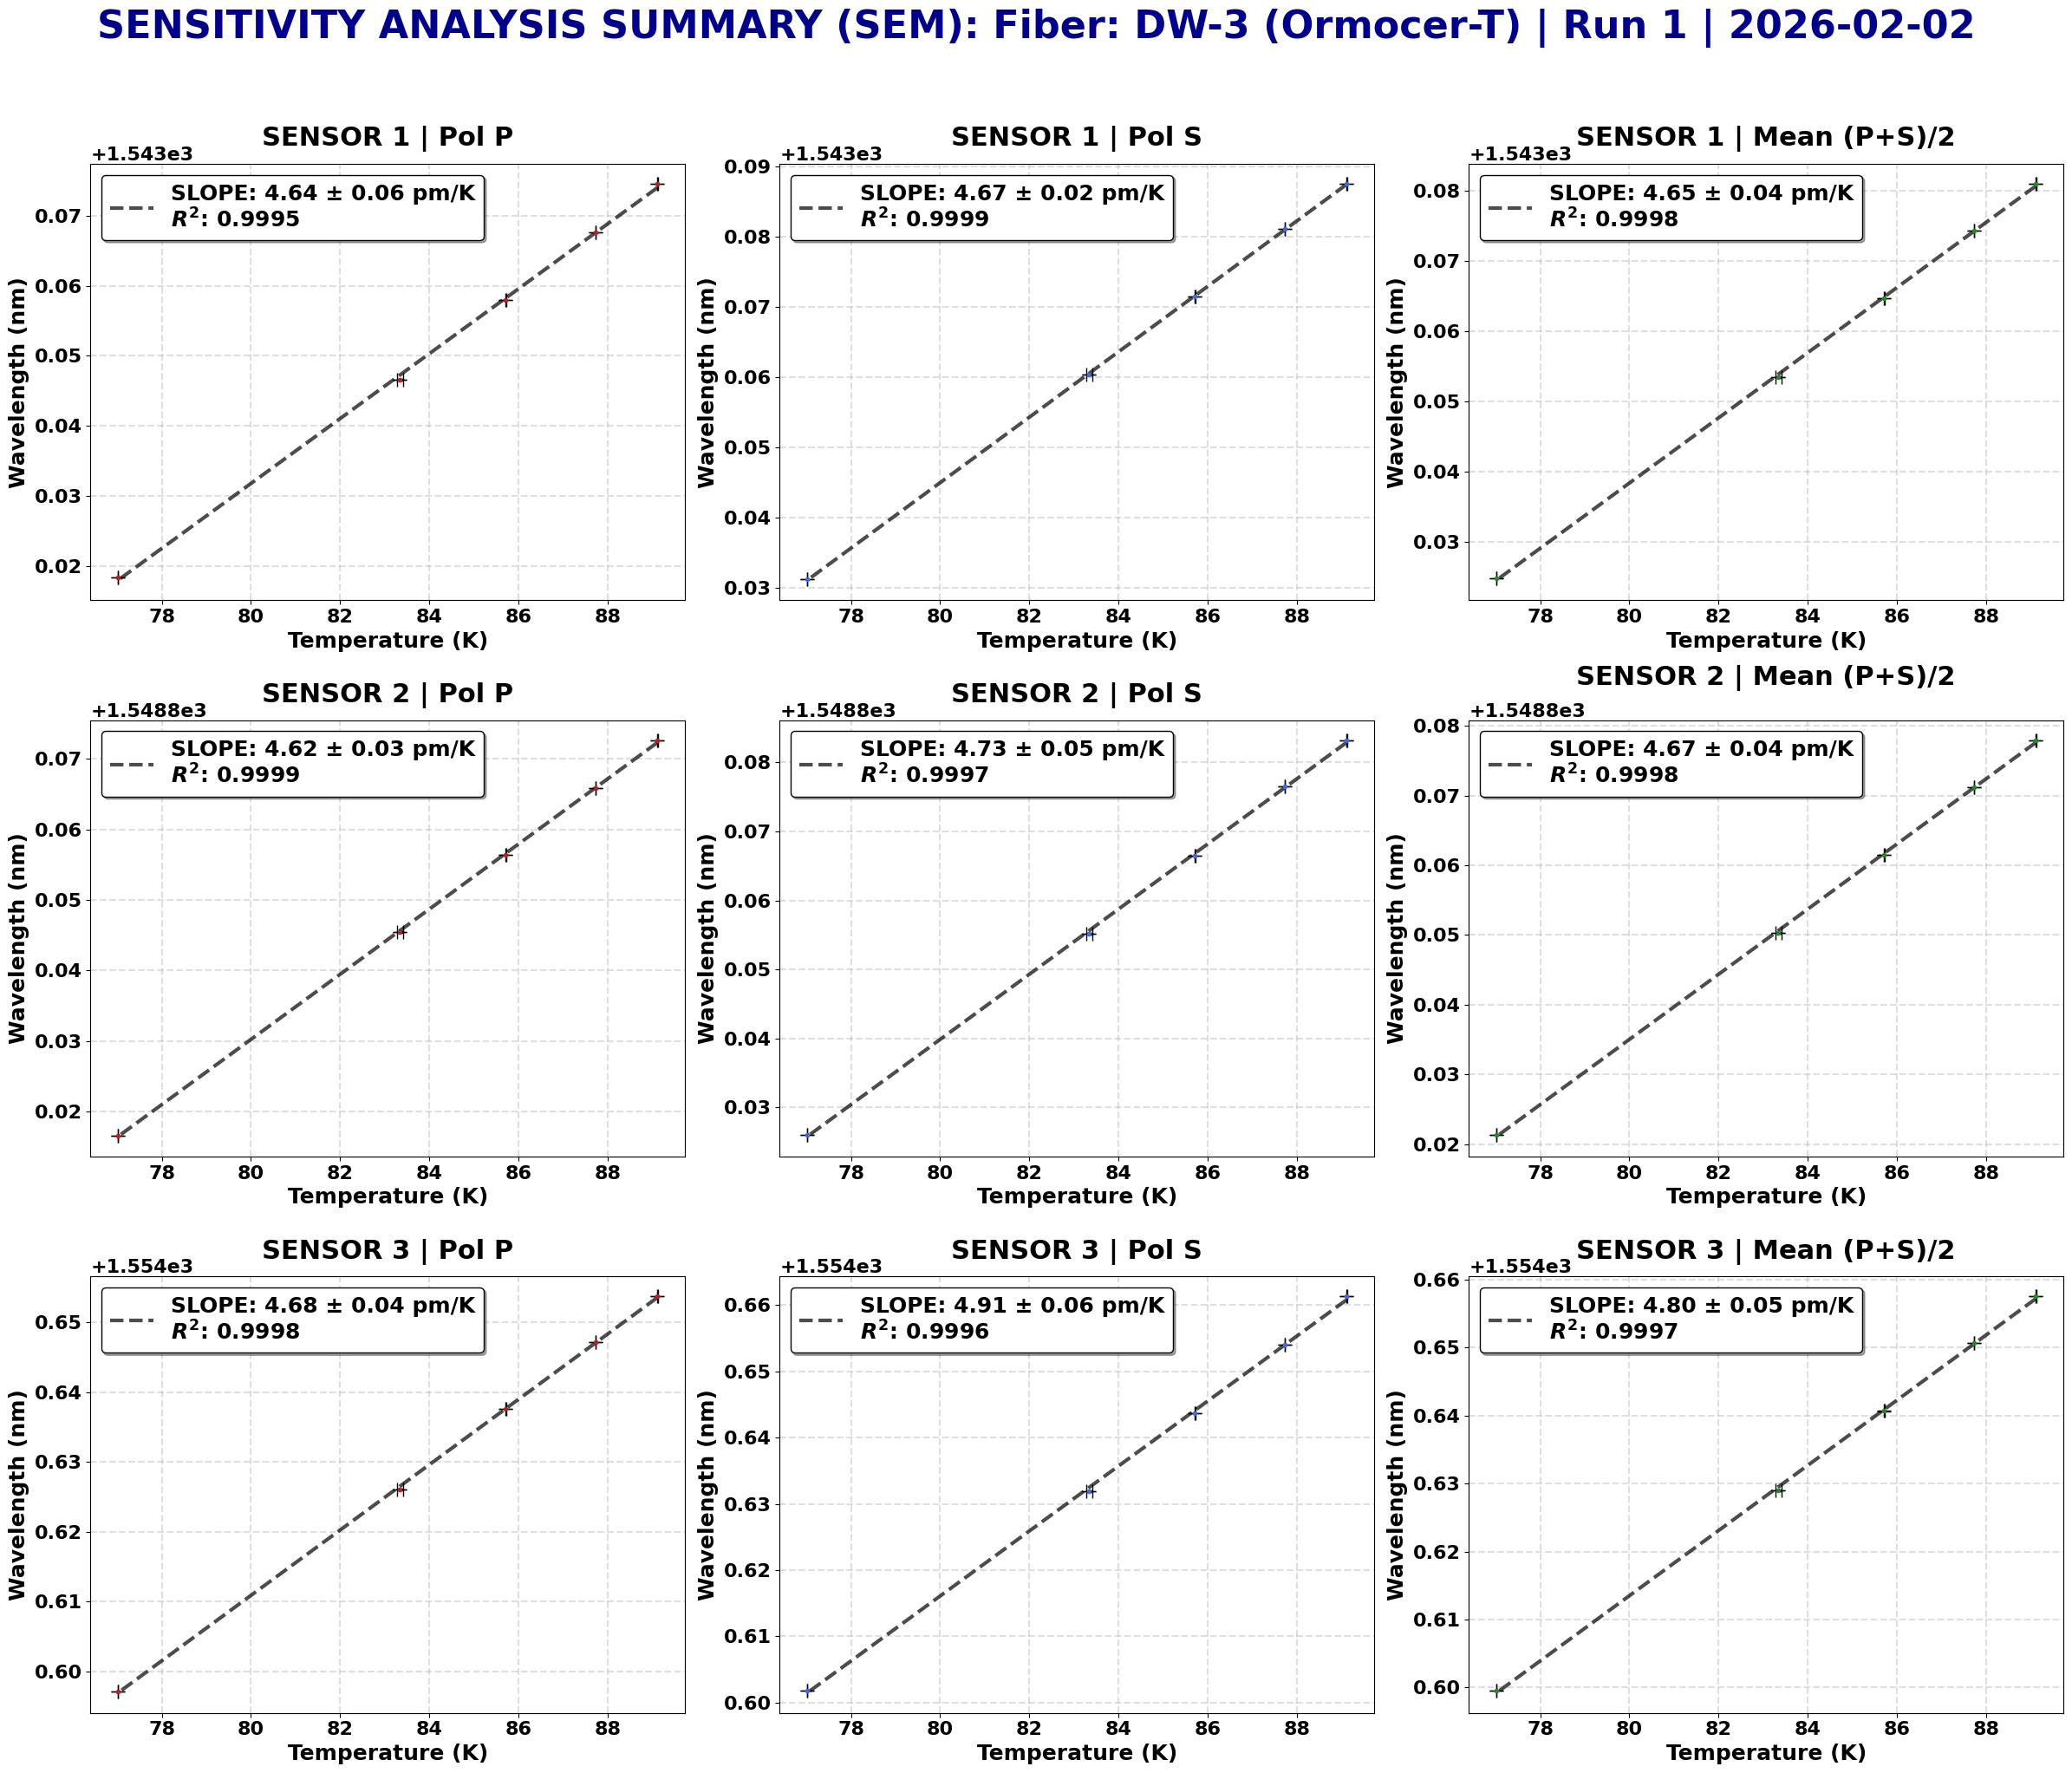


                      SENSITIVITY SUMMARY TABLE (SEM): FIBER DW-3 (Run 1)                      
Sensor   | Type            | Slope (pm/K)       | Error (pm/K)    | R²      
-----------------------------------------------------------------------------------------------
S1       | Pol P           |        4.643       |        0.062    | 0.9995
S1       | Pol S           |        4.666       |        0.020    | 0.9999
S1       | Mean (P+S)/2    |        4.654       |        0.040    | 0.9998
S2       | Pol P           |        4.619       |        0.032    | 0.9999
S2       | Pol S           |        4.727       |        0.047    | 0.9997
S2       | Mean (P+S)/2    |        4.673       |        0.038    | 0.9998
S3       | Pol P           |        4.684       |        0.038    | 0.9998
S3       | Pol S           |        4.911       |        0.057    | 0.9996
S3       | Mean (P+S)/2    |        4.797       |        0.046    | 0.9997


In [ ]:
# ============================================================================
# FINAL SENSITIVITY ANALYSIS (SEM): Fiber DW-3 | Run 1 | SINGLE HIGH-VISIBILITY FIGURE
# ============================================================================

import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import matplotlib.ticker as ticker

# Estilo global para máxima visibilidad en proyector
plt.rcParams.update({'font.weight': 'bold', 'axes.labelweight': 'bold'})

# Estructura para guardar resultados
summary_results = []
fiber_info = "Fiber: DW-3 (Ormocer-T) | Run 1 | 2026-02-02"

# --- CREAMOS UNA SOLA FIGURA (3 Sensores x 3 Tipos = 9 Subplots o 3x3) ---
fig, axes = plt.subplots(3, 3, figsize=(24, 20))

for s_idx, sensor_num in enumerate([1, 2, 3]):
    plot_configs = [
        {"key": f"FBG-{sensor_num}-P", "title": "Pol P", "color": "firebrick"},
        {"key": f"FBG-{sensor_num}-S", "title": "Pol S", "color": "royalblue"},
        {"key": f"FBG-{sensor_num}-Mean", "title": "Mean (P+S)/2", "color": "forestgreen"}
    ]

    for p_idx, config in enumerate(plot_configs):
        ax = axes[s_idx, p_idx]
        label = config["key"]
        
        t_means, t_sems, w_means, w_sems = [], [], [], []
        
        if 'plateau_data' in globals() and len(plateau_data) > 0:
            for p in plateau_data:
                source = fbg_mean_data if "Mean" in label else fbg_filtered_data
                
                if label in source:
                    mask = (source[label]["timestamps"] >= p["t0"]) & \
                           (source[label]["timestamps"] <= p["tfin"])
                    wav_data = source[label]["wavelength"][mask]

                    if len(wav_data) > 1:
                        # --- Temperature SEM ---
                        t_mean = p["temp_mean"]
                        t_sem = p["temp_std"] / np.sqrt(max(1, p.get("N_temp", 1)))

                        # --- Wavelength SEM ---
                        w_mean = np.mean(wav_data)
                        w_sem = np.std(wav_data, ddof=1) / np.sqrt(len(wav_data))

                        t_means.append(t_mean)
                        t_sems.append(t_sem)
                        w_means.append(w_mean)
                        w_sems.append(w_sem)

        x = np.array(t_means)
        y = np.array(w_means)
        x_err = np.array(t_sems)
        y_err = np.array(w_sems)

        mask_valid = ~np.isnan(x) & ~np.isnan(y)
        x, y, x_err, y_err = x[mask_valid], y[mask_valid], x_err[mask_valid], y_err[mask_valid]

        if len(x) > 1:
            slope, intercept, r_val, p_val, std_err = stats.linregress(x, y)
            slope_pm, err_pm = slope * 1e3, std_err * 1e3
            
            summary_results.append({
                "Sensor": f"S{sensor_num}",
                "Type": config["title"],
                "Slope": slope_pm,
                "Error": err_pm,
                "R2": r_val**2
            })

            # --- PLOT DE ALTA VISIBILIDAD (SEM) ---
            ax.errorbar(
                x, y,
                xerr=x_err,
                yerr=y_err,
                fmt='o',
                color=config["color"],
                ecolor='black',
                elinewidth=2.5,
                capsize=6,
                markersize=3,   # reducido para visibilidad de barras
                label='Experimental Data'
            )

            # Fit line
            ax.plot(
                x,
                slope*x + intercept,
                color='black',
                linestyle='--',
                linewidth=3,
                alpha=0.7
            )

            # Legend with slope
            slope_label = f"SLOPE: {slope_pm:.2f} ± {err_pm:.2f} pm/K\n$R^2$: {r_val**2:.4f}"
            leg = ax.legend(
                [slope_label],
                loc='upper left',
                fontsize=18,
                frameon=True,
                shadow=True,
                facecolor='white',
                edgecolor='black'
            )
            plt.setp(leg.get_texts(), fontweight='black')

            # Titles and labels (NO mention of SEM here except global title)
            ax.set_title(f"SENSOR {sensor_num} | {config['title']}", fontsize=22, fontweight='black', pad=15)
            ax.set_xlabel("Temperature (K)", fontsize=18, fontweight='bold')
            ax.set_ylabel("Wavelength (nm)", fontsize=18, fontweight='bold')

            ax.tick_params(axis='both', which='major', labelsize=16)
            for label_tick in ax.get_xticklabels() + ax.get_yticklabels():
                label_tick.set_fontweight('bold')

            ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useOffset=True))
            ax.yaxis.get_offset_text().set_fontsize(16)
            ax.yaxis.get_offset_text().set_fontweight('bold')

            ax.grid(True, alpha=0.4, linestyle='--', linewidth=1.5)

# Global title ONLY mentions SEM
plt.suptitle(
    f"SENSITIVITY ANALYSIS SUMMARY (SEM): {fiber_info}",
    fontsize=32,
    y=1.02,
    fontweight='black',
    color='darkblue'
)

plt.tight_layout()
plt.show()

# ============================================================================
# FINAL SUMMARY TABLE (IMPRESIÓN EN CONSOLA)
# ============================================================================
print("\n" + "="*95)
print(f"{'SENSITIVITY SUMMARY TABLE (SEM): FIBER DW-3 (Run 1)':^95}")
print("="*95)
print(f"{'Sensor':<8} | {'Type':<15} | {'Slope (pm/K)':<18} | {'Error (pm/K)':<15} | {'R²':<8}")
print("-" * 95)

for res in summary_results:
    print(f"{res['Sensor']:<8} | {res['Type']:<15} | {res['Slope']:>12.3f}       | {res['Error']:>12.3f}    | {res['R2']:.4f}")

print("="*95)

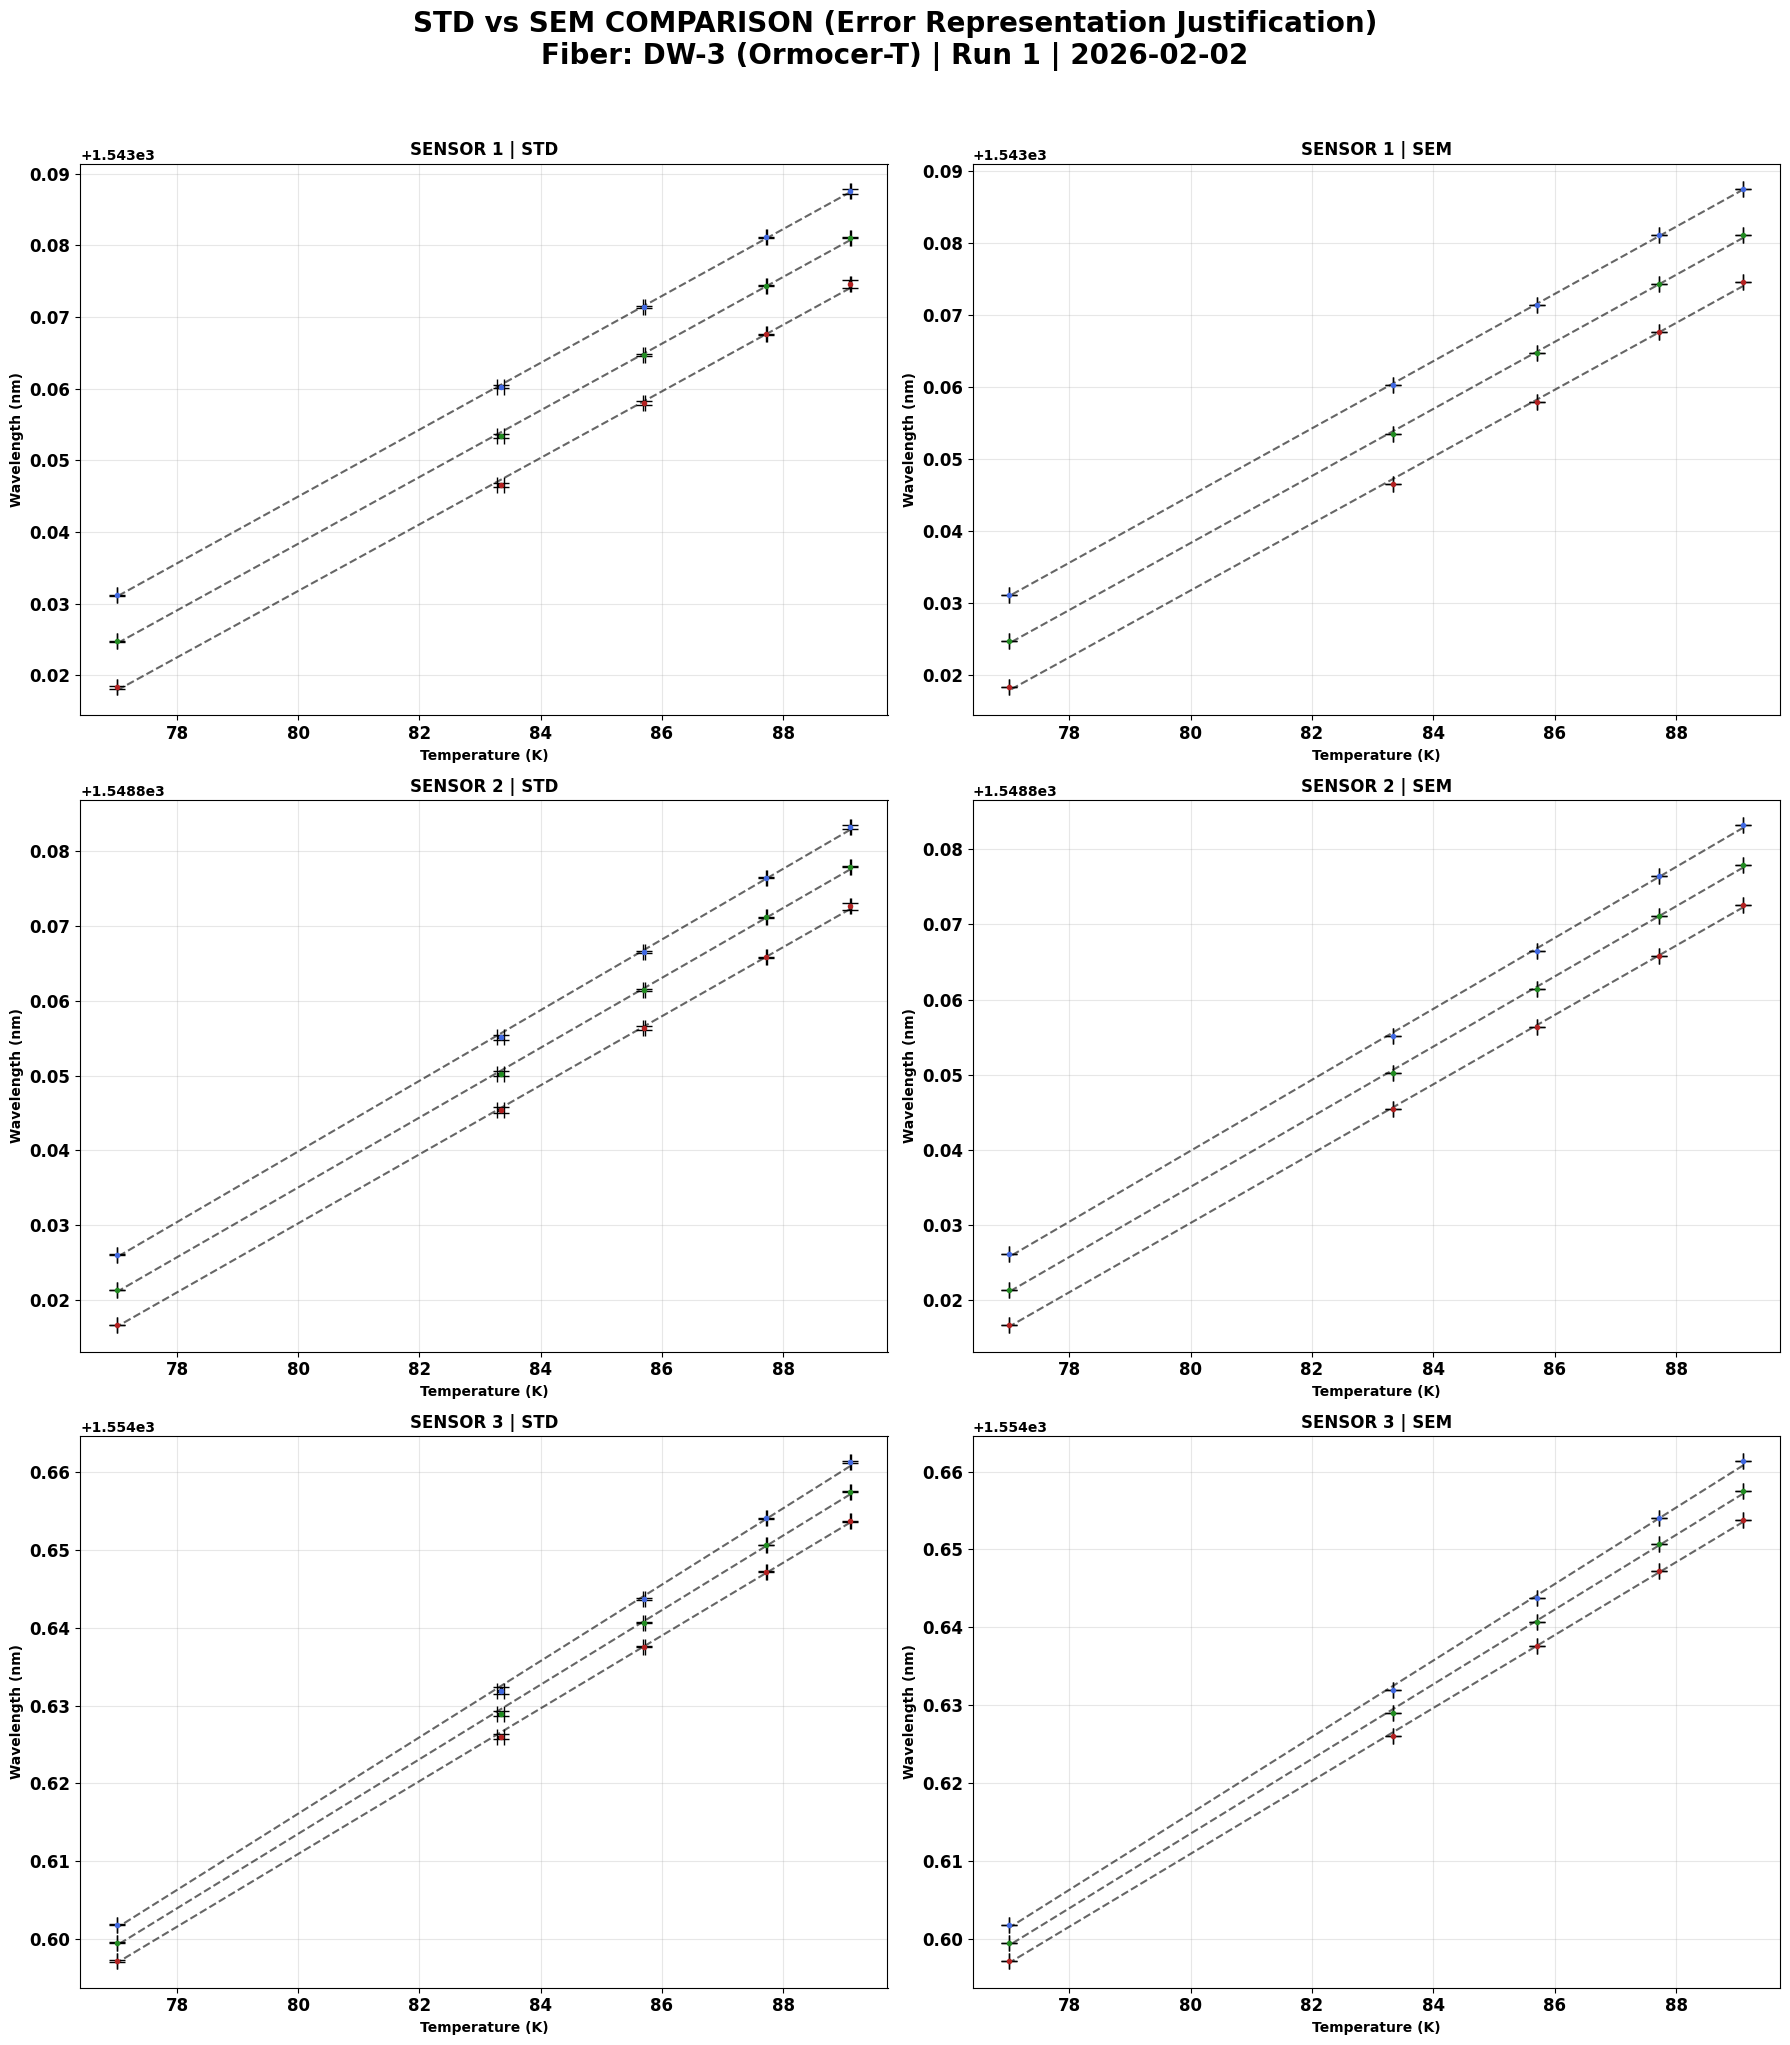

In [ ]:
# ============================================================================
# COMPARISON: STD vs SEM ERROR REPRESENTATION
# Fiber: DW-3 | Run 1 | Justification Figure
# ============================================================================

import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import matplotlib.ticker as ticker

plt.rcParams.update({'font.weight': 'bold', 'axes.labelweight': 'bold'})

fiber_info = "Fiber: DW-3 (Ormocer-T) | Run 1 | 2026-02-02"

fig, axes = plt.subplots(3, 2, figsize=(18, 20))  # col0=STD, col1=SEM

for s_idx, sensor_num in enumerate([1, 2, 3]):

    configs = [
        {"key": f"FBG-{sensor_num}-P", "color": "firebrick"},
        {"key": f"FBG-{sensor_num}-S", "color": "royalblue"},
        {"key": f"FBG-{sensor_num}-Mean", "color": "forestgreen"}
    ]

    for c_idx, cfg in enumerate(configs):

        label = cfg["key"]

        t_mean, t_std, t_sem = [], [], []
        w_mean, w_std, w_sem = [], [], []

        if 'plateau_data' in globals():

            for p in plateau_data:
                source = fbg_mean_data if "Mean" in label else fbg_filtered_data

                if label in source:
                    mask = (source[label]["timestamps"] >= p["t0"]) & \
                           (source[label]["timestamps"] <= p["tfin"])

                    wav = source[label]["wavelength"][mask]

                    if len(wav) > 1:

                        # --- X (Temperature) ---
                        Tm = p["temp_mean"]
                        Ts = p["temp_std"]
                        Tsem = Ts / np.sqrt(max(1, p.get("N_temp", len(wav))))

                        # --- Y (Wavelength) ---
                        Wm = np.mean(wav)
                        Ws = np.std(wav, ddof=1)
                        Wsem = Ws / np.sqrt(len(wav))

                        t_mean.append(Tm)
                        t_std.append(Ts)
                        t_sem.append(Tsem)

                        w_mean.append(Wm)
                        w_std.append(Ws)
                        w_sem.append(Wsem)

        x_mean = np.array(t_mean)
        y_mean = np.array(w_mean)

        # =========================
        # LEFT COLUMN → STD
        # =========================
        ax_std = axes[s_idx, 0]

        ax_std.errorbar(
            x_mean, y_mean,
            xerr=np.array(t_std),
            yerr=np.array(w_std),
            fmt='o',
            markersize=3,
            ecolor='black',
            elinewidth=2.5,
            capsize=6,
            color=cfg["color"]
        )

        if len(x_mean) > 1:
            slope, intercept, r, *_ = stats.linregress(x_mean, y_mean)
            ax_std.plot(x_mean, slope*x_mean + intercept, 'k--', alpha=0.6)

        ax_std.set_title(f"SENSOR {sensor_num} | STD", fontweight='bold')

        # =========================
        # RIGHT COLUMN → SEM
        # =========================
        ax_sem = axes[s_idx, 1]

        ax_sem.errorbar(
            x_mean, y_mean,
            xerr=np.array(t_sem),
            yerr=np.array(w_sem),
            fmt='o',
            markersize=3,
            ecolor='black',
            elinewidth=2.5,
            capsize=6,
            color=cfg["color"]
        )

        if len(x_mean) > 1:
            slope, intercept, r, *_ = stats.linregress(x_mean, y_mean)
            ax_sem.plot(x_mean, slope*x_mean + intercept, 'k--', alpha=0.6)

        ax_sem.set_title(f"SENSOR {sensor_num} | SEM", fontweight='bold')

        # --- Shared styling ---
        for ax in [ax_std, ax_sem]:
            ax.set_xlabel("Temperature (K)", fontweight='bold')
            ax.set_ylabel("Wavelength (nm)", fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.tick_params(labelsize=12)
            for t in ax.get_xticklabels() + ax.get_yticklabels():
                t.set_fontweight('bold')

fig.suptitle(
    f"STD vs SEM COMPARISON (Error Representation Justification)\n{fiber_info}",
    fontsize=20,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

## 7️⃣ Evolución Temporal Completa (Todo el rango con TIME_SHIFT aplicado)

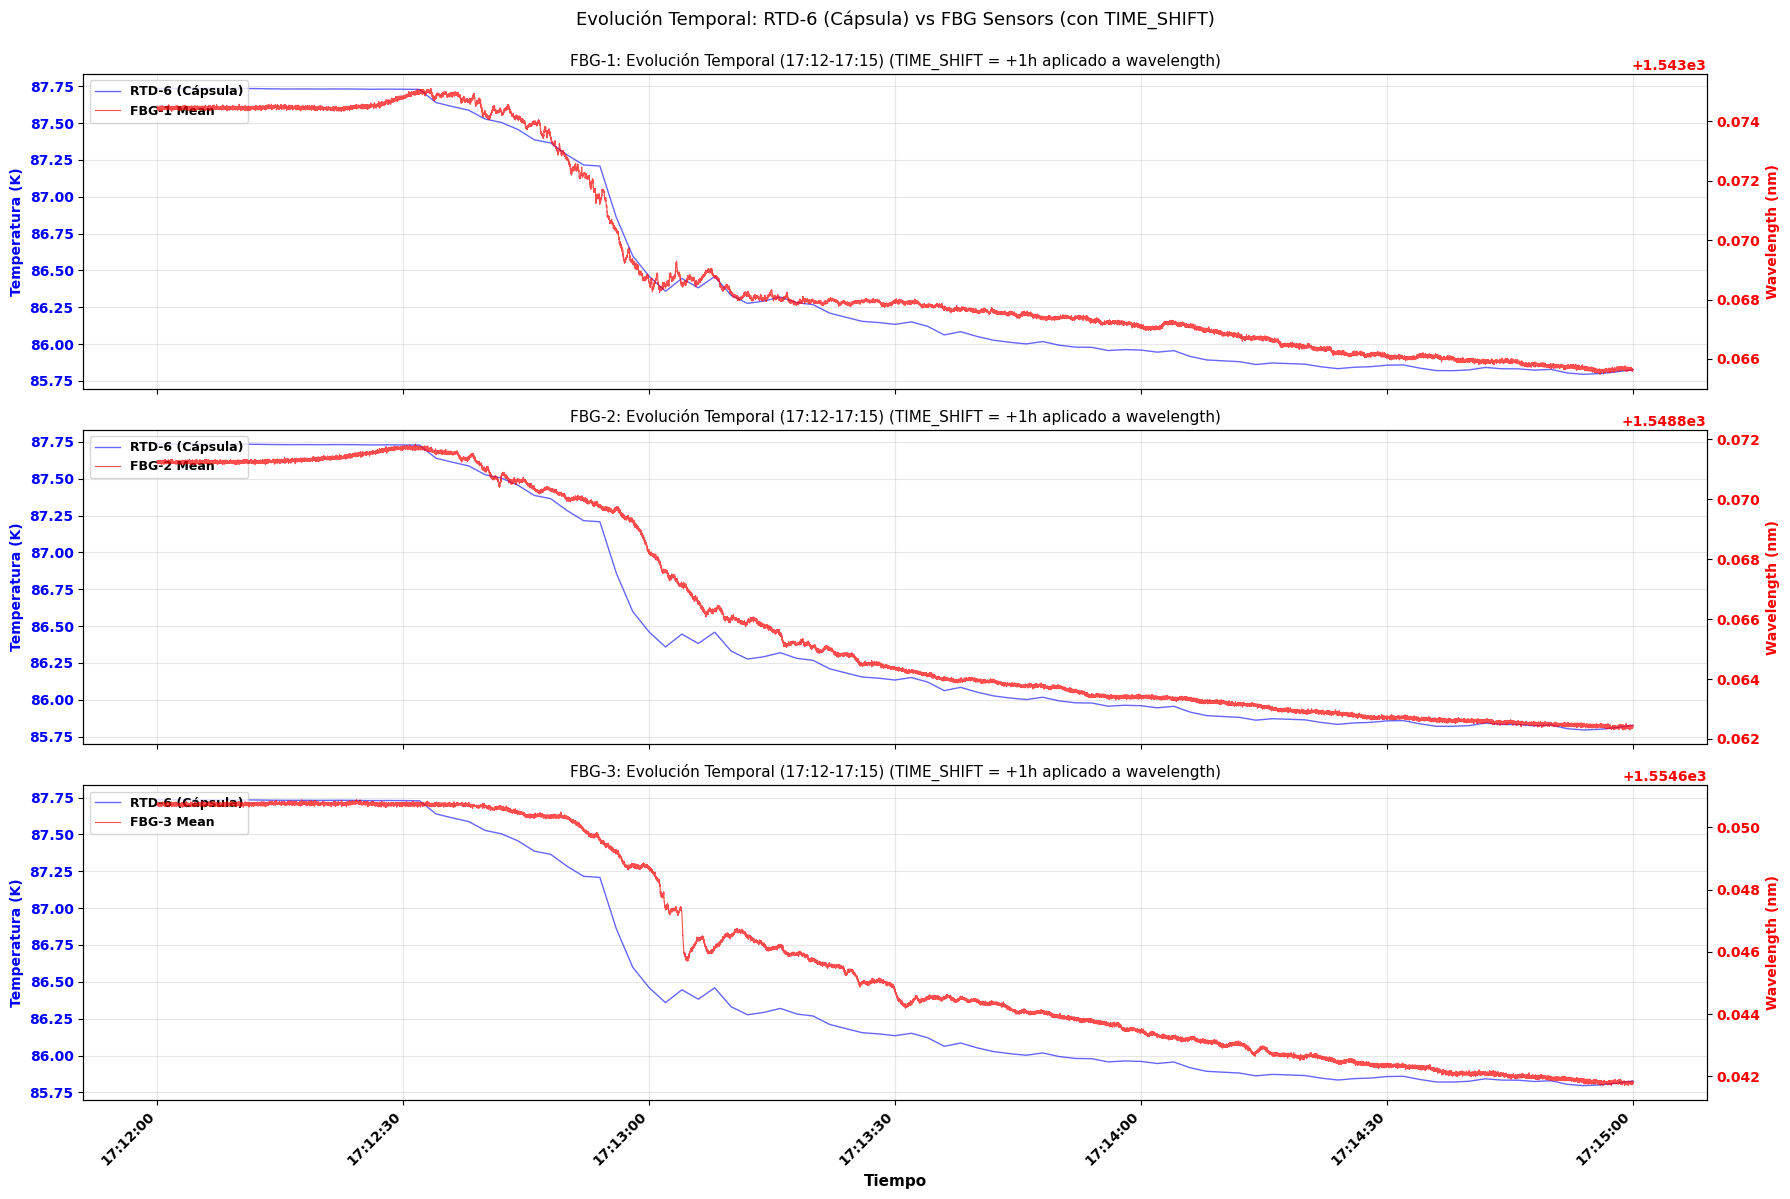


📊 Rango temporal mostrado: (17:12-17:15)
   Temperatura: 2026-02-02 17:12 - 17:15
   Wavelength (con +1h shift): 2026-02-02 17:12 - 17:14

💡 Este gráfico muestra el TIME_SHIFT de 1 horas aplicado a los datos de wavelength
   para alinearlos temporalmente con la temperatura.

⚙️  Para ver el rango completo: cambia 'use_filtered_range_plot = False'


In [ ]:
# ============================================================================
# CONFIGURACIÓN: Filtrar por rango temporal (opcional)
# ============================================================================
# Opción A: Mostrar TODO el rango temporal disponible
use_filtered_range_plot = True  # Cambiar a True para filtrar por un rango específico

if use_filtered_range_plot:
    # Opción B: Definir rango específico para visualización
    # Puedes usar el mismo rango de la Sección 3 o definir uno personalizado
    t_plot_inicio = datetime.datetime.combine(fecha, datetime.time(17, 12))
    t_plot_fin = datetime.datetime.combine(fecha, datetime.time(17, 15))
    range_label = f"({t_plot_inicio.strftime('%H:%M')}-{t_plot_fin.strftime('%H:%M')})"
else:
    # Mostrar todo el rango disponible
    t_plot_inicio = times_temp[0]
    t_plot_fin = times_temp[-1]
    range_label = "(Rango completo)"
# ============================================================================

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

# Filtrar datos de temperatura según rango seleccionado
temp_raw_valid_mask = (temp_raw[:, rtd_ref_idx] > 0) & \
                       (times_temp >= t_plot_inicio) & \
                       (times_temp <= t_plot_fin)
times_temp_plot = times_temp[temp_raw_valid_mask]
temp_plot = temp_raw[temp_raw_valid_mask, rtd_ref_idx]

for idx, sensor_num in enumerate([1, 2, 3]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    
    # Extraer datos RAW completos
    sensor_idx = sensor_num - 1  # 0-indexed
    wav_p_full = wav_raw[:, 0, sensor_idx]  # Polarización P
    wav_s_full = wav_raw[:, 1, sensor_idx]  # Polarización S
    
    # Filtrar valores positivos y por rango temporal
    mask_p = (wav_p_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    mask_s = (wav_s_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    
    times_p_plot = times_peak[mask_p]
    times_s_plot = times_peak[mask_s]
    wav_p_plot_valid = wav_p_full[mask_p]
    wav_s_plot_valid = wav_s_full[mask_s]
    
    # Interpolar S a tiempos de P
    times_p_sec = np.array([t.timestamp() for t in times_p_plot])
    times_s_sec = np.array([t.timestamp() for t in times_s_plot])
    wav_s_interp_plot = np.interp(times_p_sec, times_s_sec, wav_s_plot_valid)
    
    # Media (P+S)/2
    wav_mean_plot = (wav_p_plot_valid + wav_s_interp_plot) / 2.0
    
    ax = axes[idx]
    
    # Plot temperatura
    ax.plot(times_temp_plot, temp_plot, 'b-', linewidth=1.0, alpha=0.6, label=f'{rtd_ref_name}')
    ax.set_ylabel('Temperatura (K)', fontsize=10, color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.grid(True, alpha=0.3)
    
    # Plot wavelength en eje secundario
    ax2 = ax.twinx()
    ax2.plot(times_p_plot, wav_mean_plot, 'r-', linewidth=0.8, alpha=0.7, label=f'FBG-{sensor_num} Mean')
    ax2.set_ylabel('Wavelength (nm)', fontsize=10, color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    
    # Leyenda combinada
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    
    ax.set_title(f'FBG-{sensor_num}: Evolución Temporal {range_label} (TIME_SHIFT = +{TIME_SHIFT.total_seconds()/3600:.0f}h aplicado a wavelength)', 
                 fontsize=11)

# Configurar eje X solo en el último subplot
axes[-1].set_xlabel('Tiempo', fontsize=11)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Evolución Temporal: {rtd_ref_name} vs FBG Sensors (con TIME_SHIFT)', 
             fontsize=13, y=0.995)
plt.tight_layout()
plt.show()

print(f"\n📊 Rango temporal mostrado: {range_label}")
print(f"   Temperatura: {times_temp_plot[0].strftime('%Y-%m-%d %H:%M')} - {times_temp_plot[-1].strftime('%H:%M')}")
print(f"   Wavelength (con +{TIME_SHIFT.total_seconds()/3600:.0f}h shift): {times_p_plot[0].strftime('%Y-%m-%d %H:%M')} - {times_p_plot[-1].strftime('%H:%M')}")
print(f"\n💡 Este gráfico muestra el TIME_SHIFT de {TIME_SHIFT.total_seconds()/3600:.0f} horas aplicado a los datos de wavelength")
print(f"   para alinearlos temporalmente con la temperatura.")
if use_filtered_range_plot:
    print(f"\n⚙️  Para ver el rango completo: cambia 'use_filtered_range_plot = False'")
else:
    print(f"\n⚙️  Para filtrar por rango temporal específico: cambia 'use_filtered_range_plot = True'")